# Lab Day 1 — Hoàng Trung Anh — 2A202602521

Lượt sửa theo rubric trên Colab T4. Đã biết điểm eval của lượt cũ; giữ lịch sử trong Git. Các dự đoán và lưới mới được lưu trước khi chạy, không chỉnh cấu hình theo eval mới. Notebook giữ output thực từ Restart & Run All. Mở cùng các module trong submission_2A202602521/code/.

## Part 0 — Dữ liệu và môi trường

Giữ nguyên metadata; val 20% train, stratify seed 42; fit 10 cột số bằng train. Mỗi run dùng process mới và cùng dữ liệu để so peak memory. Bản nộp trước được sao lưu trong .lab_history khi chạy lại.

In [1]:
import os, sys, shutil, subprocess, tempfile, json
from pathlib import Path
import torch
from IPython.display import display, Image
start=Path.cwd()
root=next((p for p in [start,*start.parents] if (p/'scripts/evaluate.py').exists()),None)
if root is None:
    root=Path('/content/K4-Track4-Day1-Neuralnetwork')
    if not root.exists():
        subprocess.run(['git','clone','https://github.com/trungKoiKa/K4-Track4-Day1-Neuralnetwork.git',str(root)],check=True)
assert torch.cuda.is_available(), 'Select T4 GPU in Colab.'
source=start if (start/'protocol.py').exists() else root/'code'
out=root/'submission_2A202602521'
# Preserve the previous run before creating a fresh prospective submission.
backup=root/'.lab_history'; backup.mkdir(exist_ok=True)
if out.exists():
    target=backup/Path(tempfile.mkdtemp()).name
    relative_source=source.relative_to(out) if source.is_relative_to(out) else None
    shutil.move(str(out),str(target))
    if relative_source is not None: source=target/relative_source
out.mkdir(); shutil.copytree(source,out/'code')
os.chdir(root); sys.path.insert(0,str(out/'code'))
subprocess.run([sys.executable,'scripts/split_data.py'],check=True)
from protocol import stage, OUT
stage('setup')
print(torch.__version__,torch.cuda.get_device_name(0))
print(json.loads((OUT/'protocol.json').read_text(encoding='utf-8')))


PROSPECTIVE_PLAN_SAVED /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602521/protocol.json


2.11.0+cu130 Tesla T4
{'created_utc': '2026-10-03T09:17:12Z', 'prior_eval_seen': True, 'reason': 'Repair rubric compliance, not tune to eval scores.', 'selection': 'maximum validation macro-F1 at minimum validation-loss epoch; tie: exp_id', 'baseline_lr_grid': [0.01, 0.05, 0.1], 'adam_lr_grid': [0.0003, 0.001, 0.003], 'hypotheses': {'baseline': 'SGD momentum: lr thấp học chậm, lr cao có thể dao động; chọn lr bằng F1 val tại epoch min val loss.', 'loss': 'CE phù hợp phân lớp hơn MSE logits/one-hot; chỉ so accuracy/F1, không so trị số loss khác thang.', 'optimizer': 'Adam/AdamW có thể hội tụ nhanh hơn SGD; thử cùng lưới lr cho từng optimizer và so lr tốt nhất.', 'hyperparameter': 'Batch 2048 giảm số bước/epoch bốn lần so batch 512, có thể làm học chậm với lr giữ nguyên.', 'dropout': 'p=0.3 có thể giảm train-val gap nhưng giảm F1 nếu mạng chưa overfit.', 'clipping': 'lr gấp 10 có thể gây dao động; clip ở phân vị 90 gradient baseline có thể giảm bước cực lớn, không chắc cứu được phân kỳ.',

## Part 1 — Model và kiểm tra sức khoẻ

Dự đoán: logits uniform cho CE=ln7; He có logits biến thiên nên CE có thể cao hơn. Model phải có 47 879 tham số, logits (B,7), gradient khác 0 và overfit 20 mẫu đạt 100%. Init zeros giữ đối xứng; std sau ReLU bằng 0. Đo activation trên lô validation trước huấn luyện.

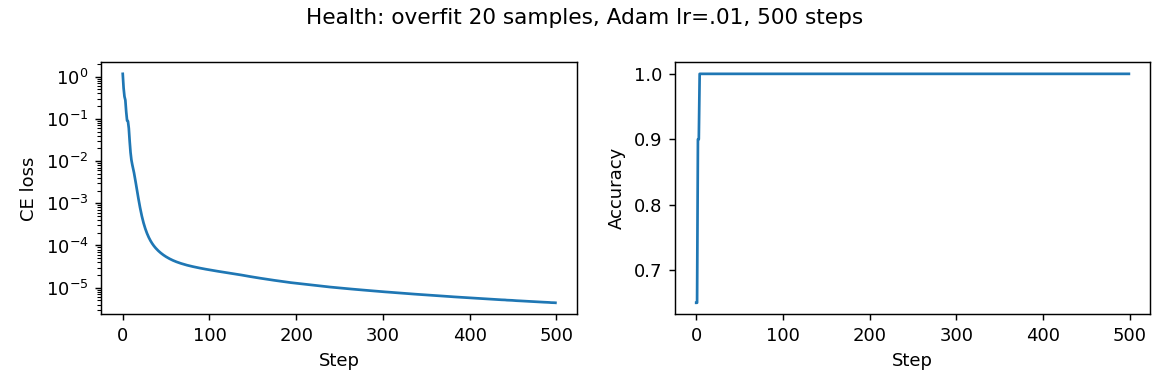

HEALTH_PASSED_BEFORE_TRAINING


In [2]:
stage('health')
display(Image(filename=str(OUT/'figures/health_overfit20.png')))
print('HEALTH_PASSED_BEFORE_TRAINING')

## Part 2 — Baseline và pipeline

Dự đoán: SGD momentum 0,9 có thể học chậm ở lr=.01, lr=.1 có thể dao động. Lưới .01/.05/.1, batch512, 20epoch, CE, He, FP32. Chọn lr qua F1 val tại epoch min val loss, rồi lặp seed1/2/3. Train loss đo eval mode; gradient trước clip, cờ diverged và memory/time được ghi.

In [3]:
stage('pilots')
stage('baseline')

BASELINE_LR_SELECTED_BY_VAL 0.1


val_acc mean 0.9081560207396571 sample std 0.002443634368564064
val_macro_f1 mean 0.8535103397282485 sample std 0.012554754389219557


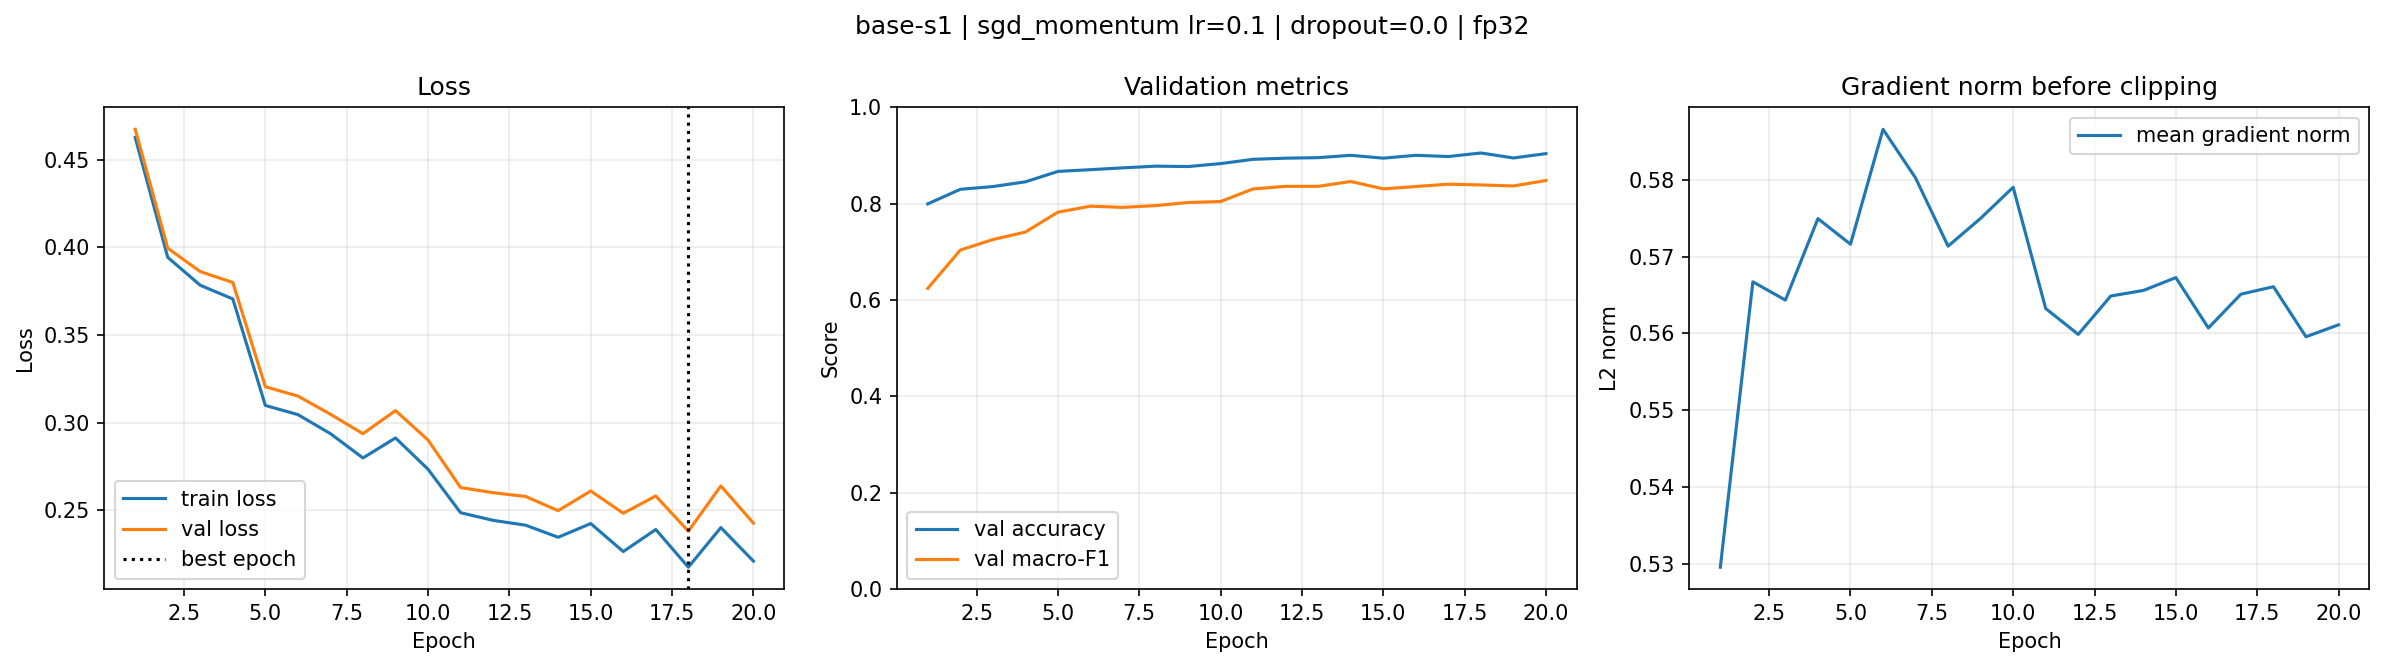

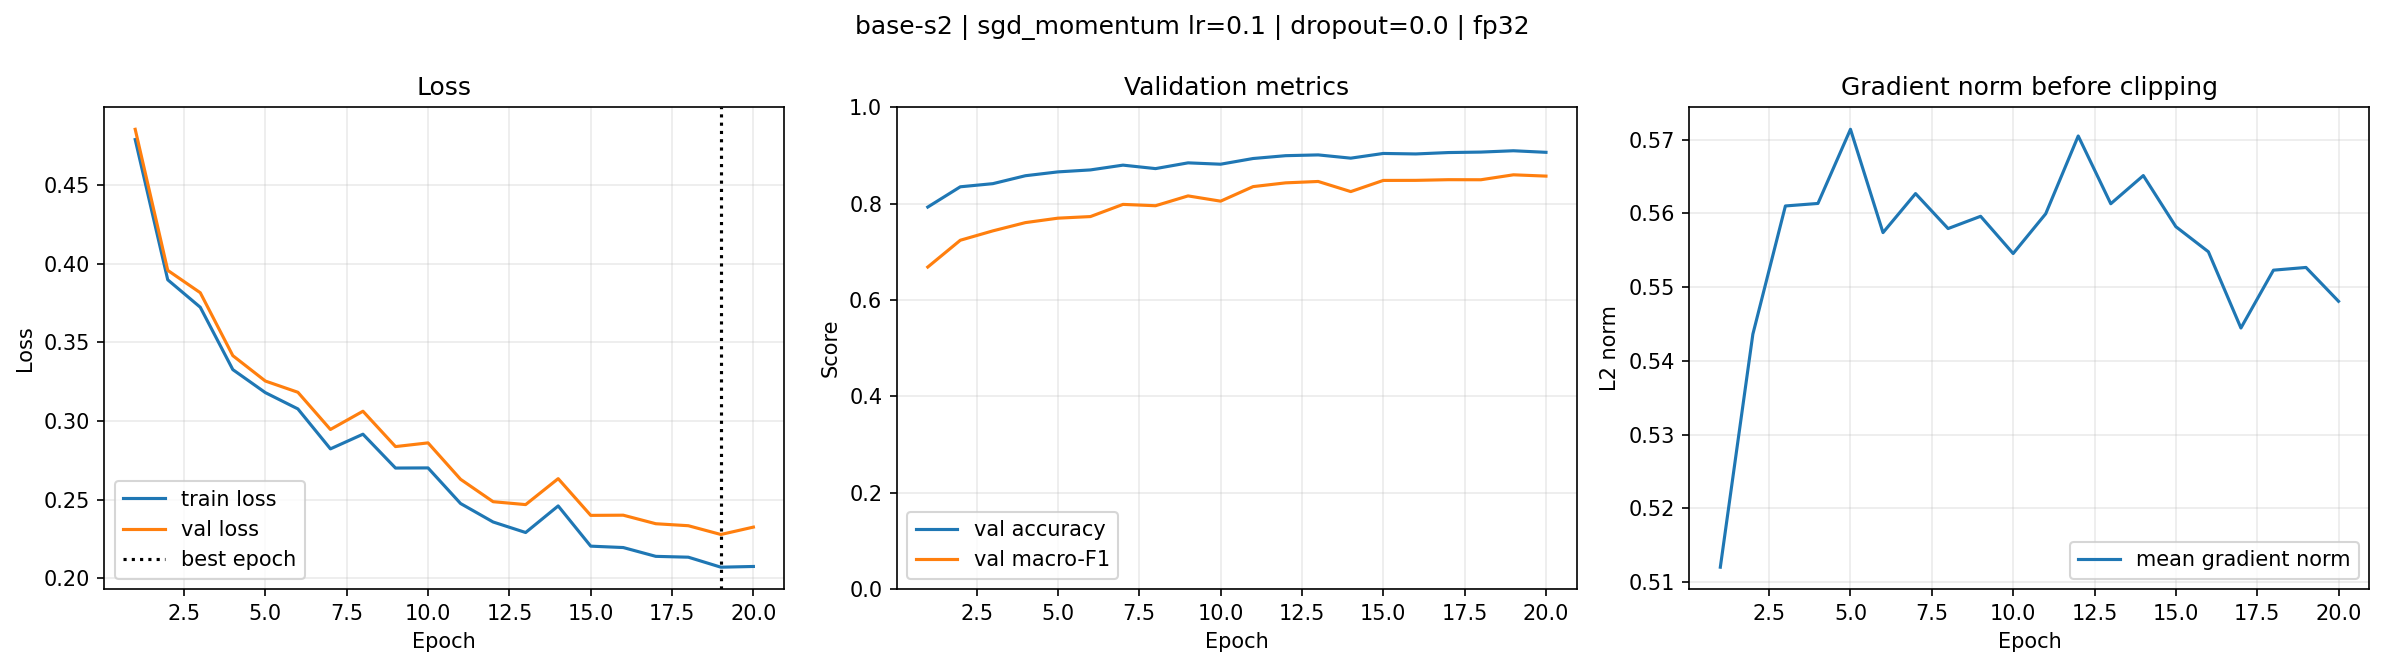

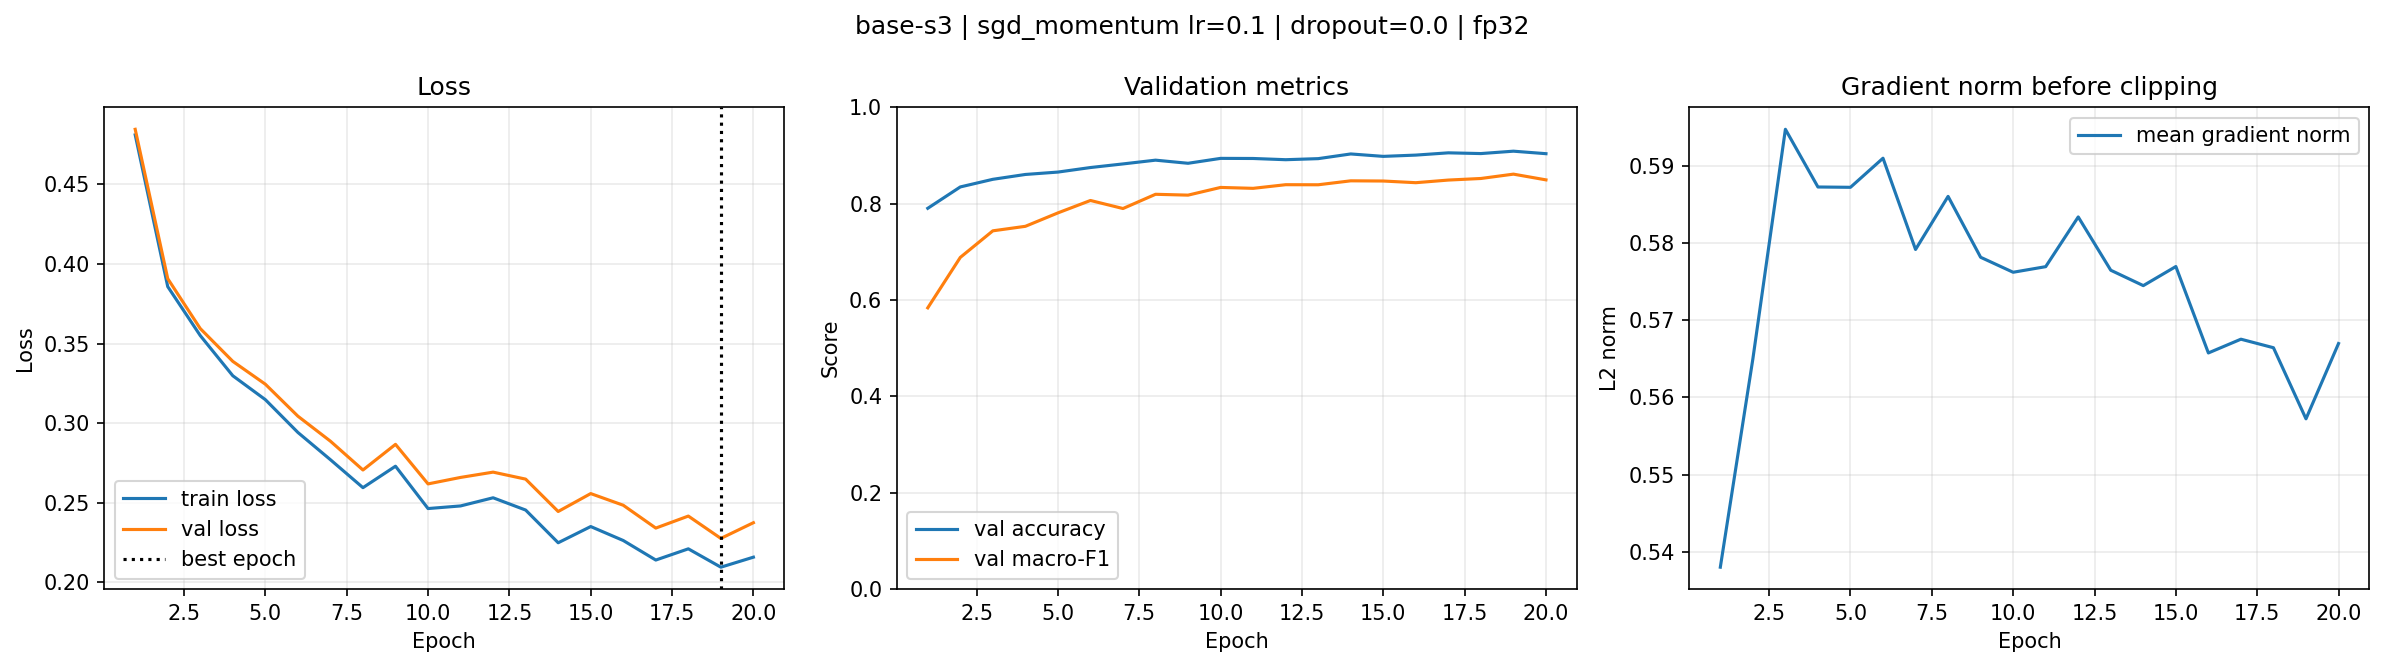

In [4]:
from results_table import load_results
import numpy as np
seeds=[r for r in load_results(OUT/'results') if r['cfg']['exp_id'] in ['base-s1','base-s2','base-s3']]
for key in ['val_acc','val_macro_f1']:
    values=[r['summary'][key] for r in seeds]
    print(key,'mean',np.mean(values),'sample std',np.std(values,ddof=1))
for r in seeds: display(Image(filename=str(OUT/'figures'/f"{r['cfg']['exp_id']}.png")))

## Part 3 — Thí nghiệm có dự đoán trước

- Loss: CE có thể tốt hơn MSE logits/one-hot, so metric khác thang loss.
- Optimizer: Adam có thể hội tụ nhanh hơn; mỗi Adam/AdamW thử .0003/.001/.003, giữ batch512. Optimizer và lr đổi cùng nhau có chủ đích để tuning công bằng.
- Hyperparameter: batch2048 giảm update/epoch, có thể học chậm nếu giữ lr.
- Dropout: p=.3 có thể giảm gap nhưng giảm F1 nếu chưa overfit.
- Clipping: c lấy phân vị90 gradient batch baseline; lr cao gấp10 có thể dao động, clip không chắc cứu được. So cặp cùng lr trước khi kết luận.
- Precision: MLP nhỏ có thể không nhanh hơn; FP16 scaler/unscale, BF16 không native trên T4.
- Init: normal nhỏ giảm tín hiệu, He giữ tín hiệu qua ReLU, zeros không phá đối xứng.

Mỗi cấu hình/hypothesis/timestamp được ghi planned/<exp_id>.json trước worker. Giữ checkpoint ngoài bài nộp để không cần huấn luyện lại lấy trọng số.

In [5]:
stage('experiments')

adam-lr0.0003 Prediction: Adam/AdamW có thể hội tụ nhanh hơn SGD; thử cùng lưới lr cho từng optimizer và so lr tốt nhất.
Observed F1: 0.7877390598660482 delta: -0.05129669648982316 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


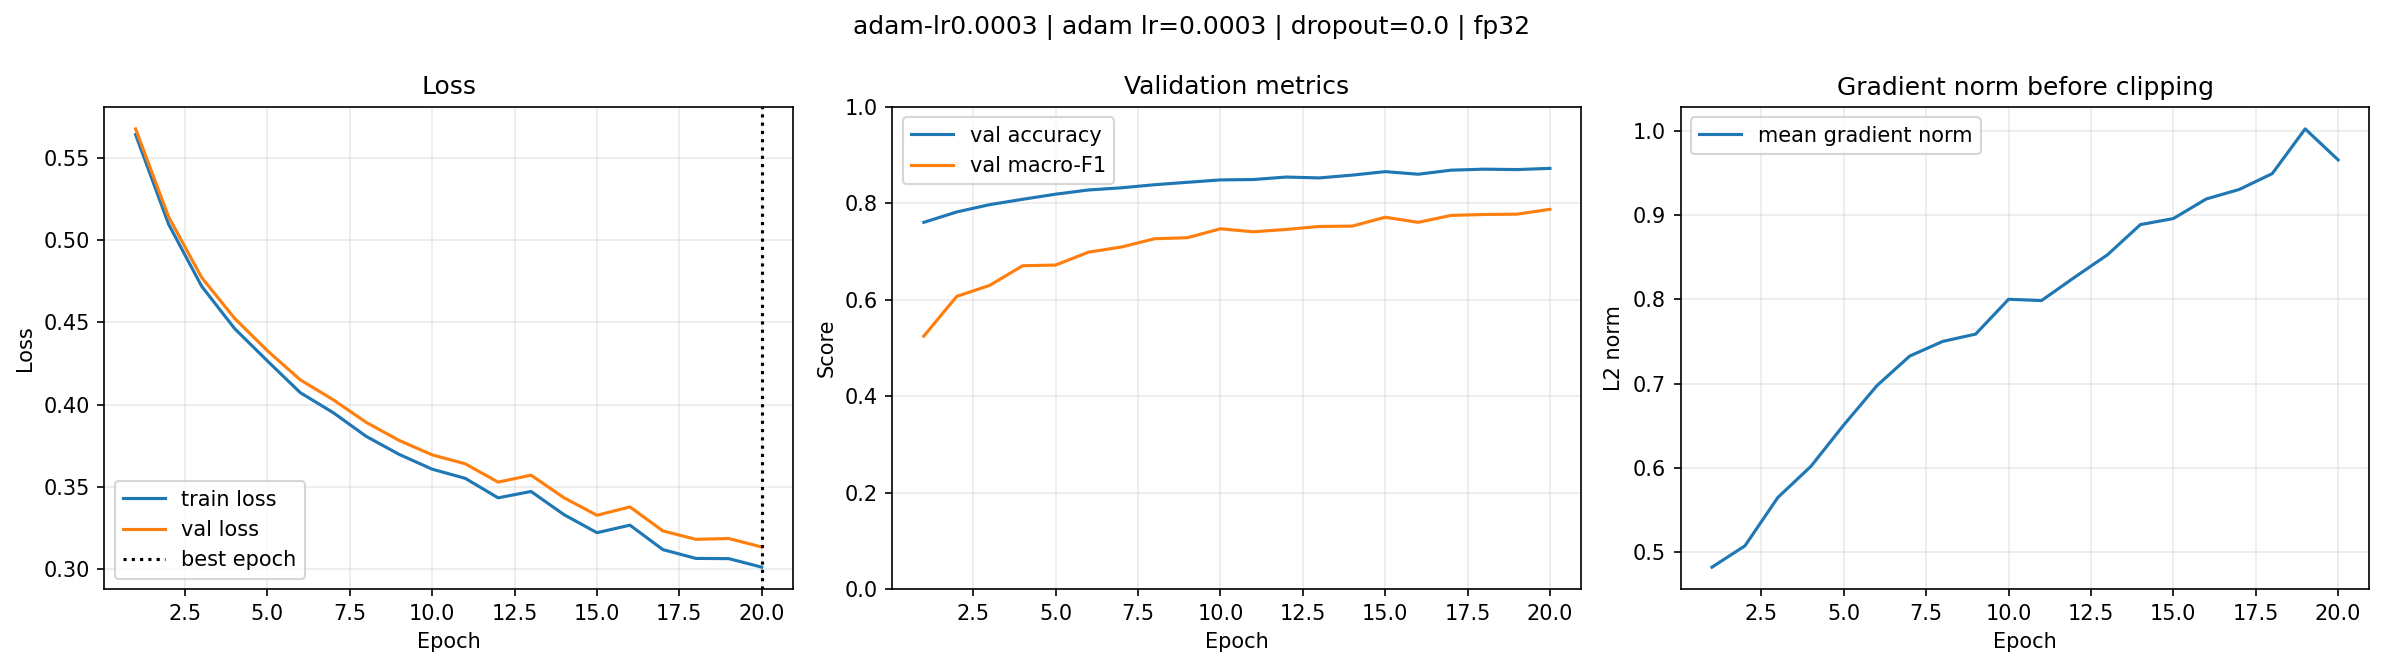

adam-lr0.001 Prediction: Adam/AdamW có thể hội tụ nhanh hơn SGD; thử cùng lưới lr cho từng optimizer và so lr tốt nhất.
Observed F1: 0.845555844686964 delta: 0.006520088331092633 beyond baseline 2 sigma: False diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


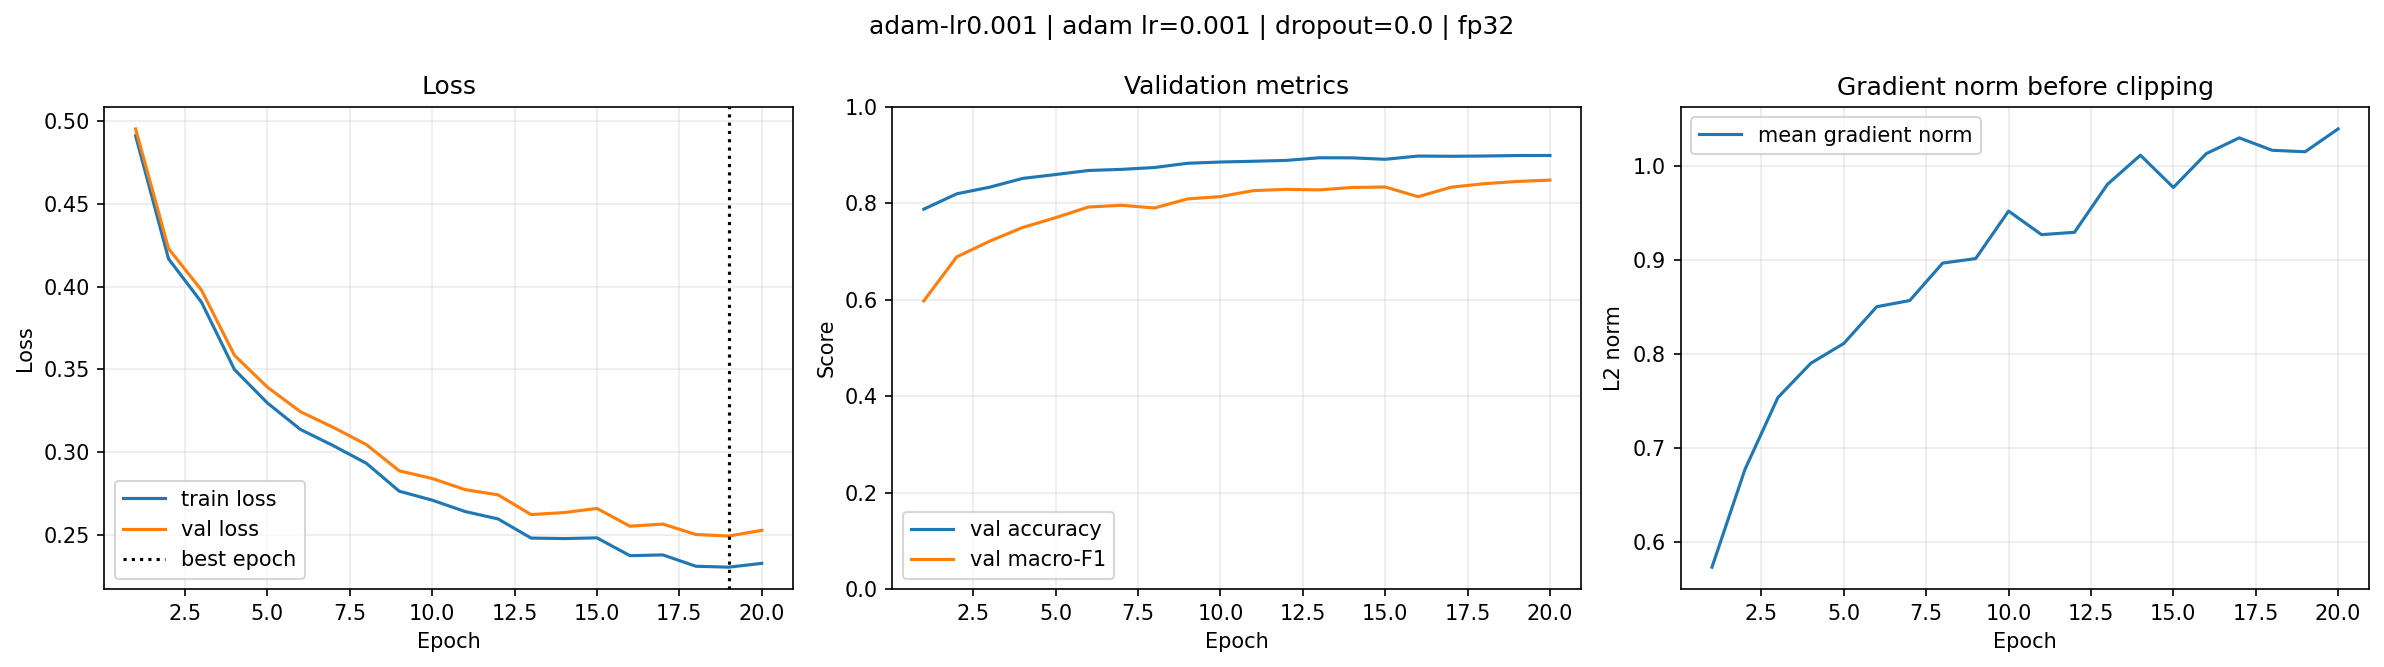

adam-lr0.003 Prediction: Adam/AdamW có thể hội tụ nhanh hơn SGD; thử cùng lưới lr cho từng optimizer và so lr tốt nhất.
Observed F1: 0.8677466182111557 delta: 0.028710861855284375 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


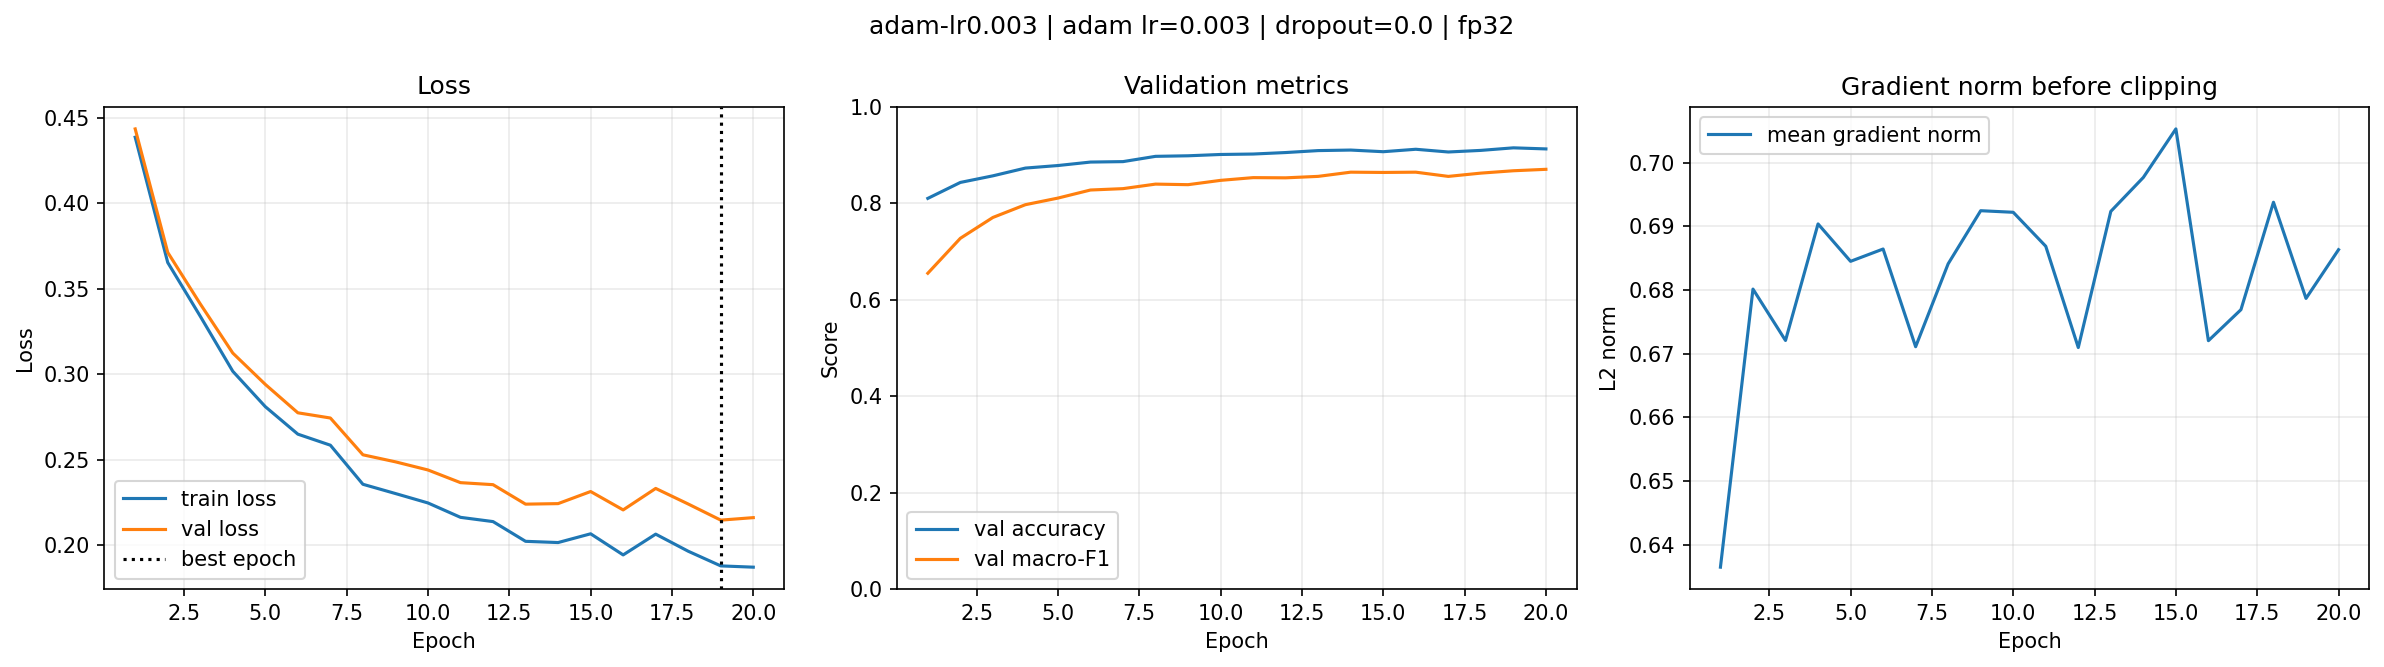

adamw-lr0.0003 Prediction: Adam/AdamW có thể hội tụ nhanh hơn SGD; thử cùng lưới lr cho từng optimizer và so lr tốt nhất.
Observed F1: 0.7877390598660482 delta: -0.05129669648982316 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


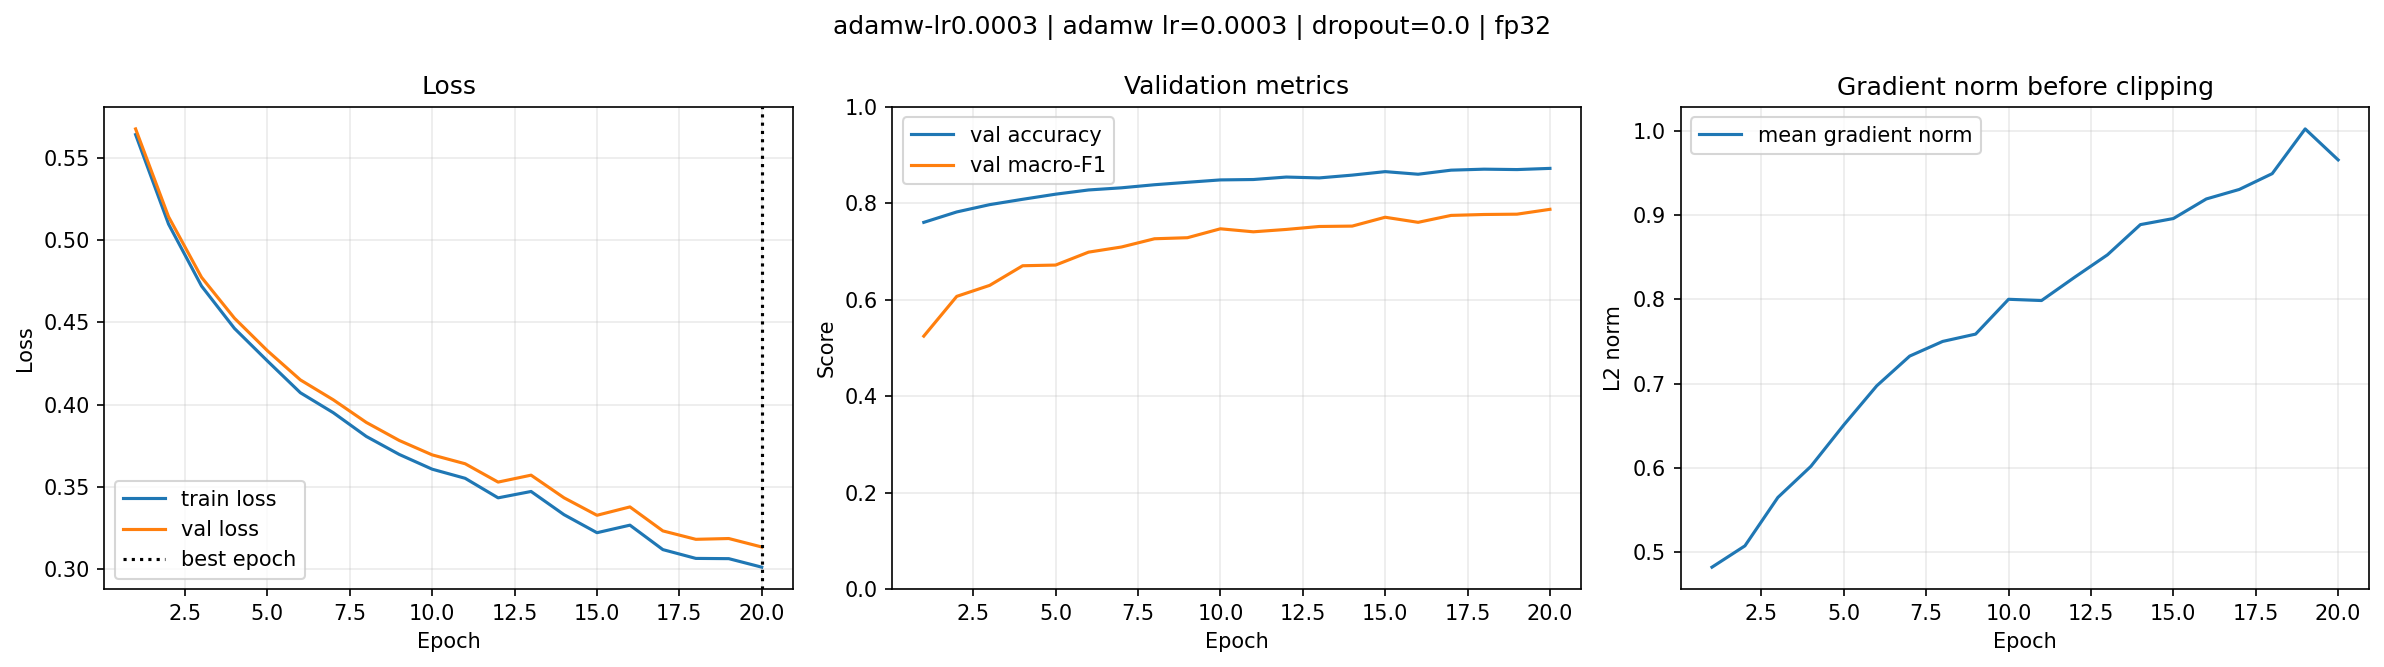

adamw-lr0.001 Prediction: Adam/AdamW có thể hội tụ nhanh hơn SGD; thử cùng lưới lr cho từng optimizer và so lr tốt nhất.
Observed F1: 0.845555844686964 delta: 0.006520088331092633 beyond baseline 2 sigma: False diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


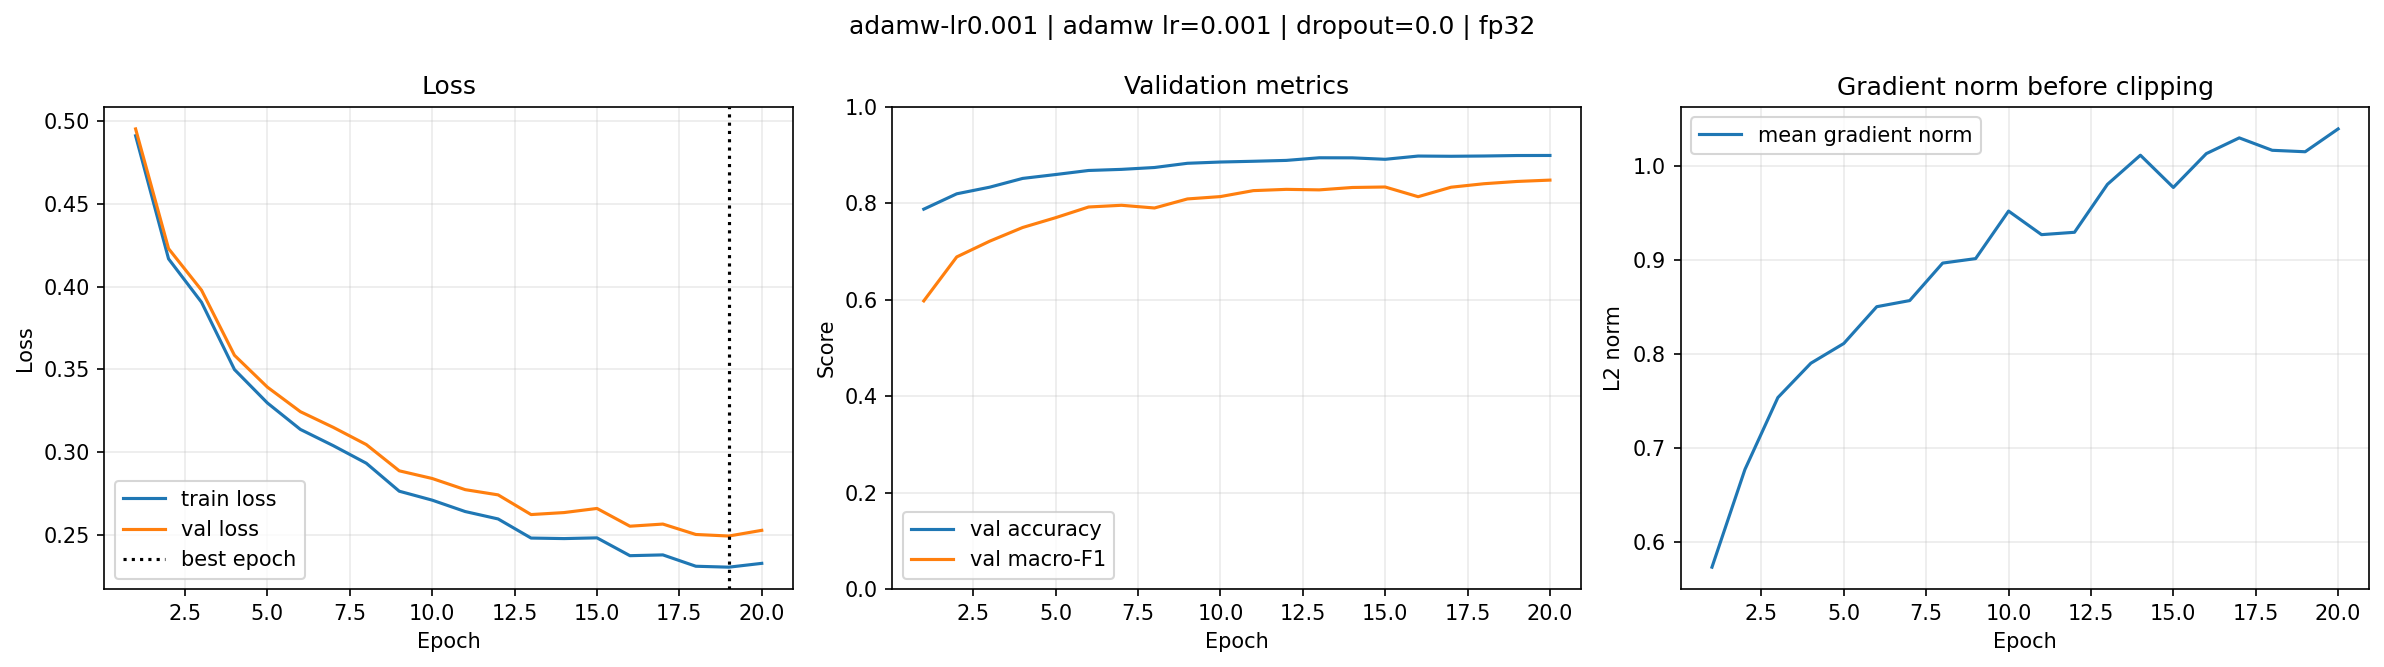

adamw-lr0.003 Prediction: Adam/AdamW có thể hội tụ nhanh hơn SGD; thử cùng lưới lr cho từng optimizer và so lr tốt nhất.
Observed F1: 0.8677466182111557 delta: 0.028710861855284375 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


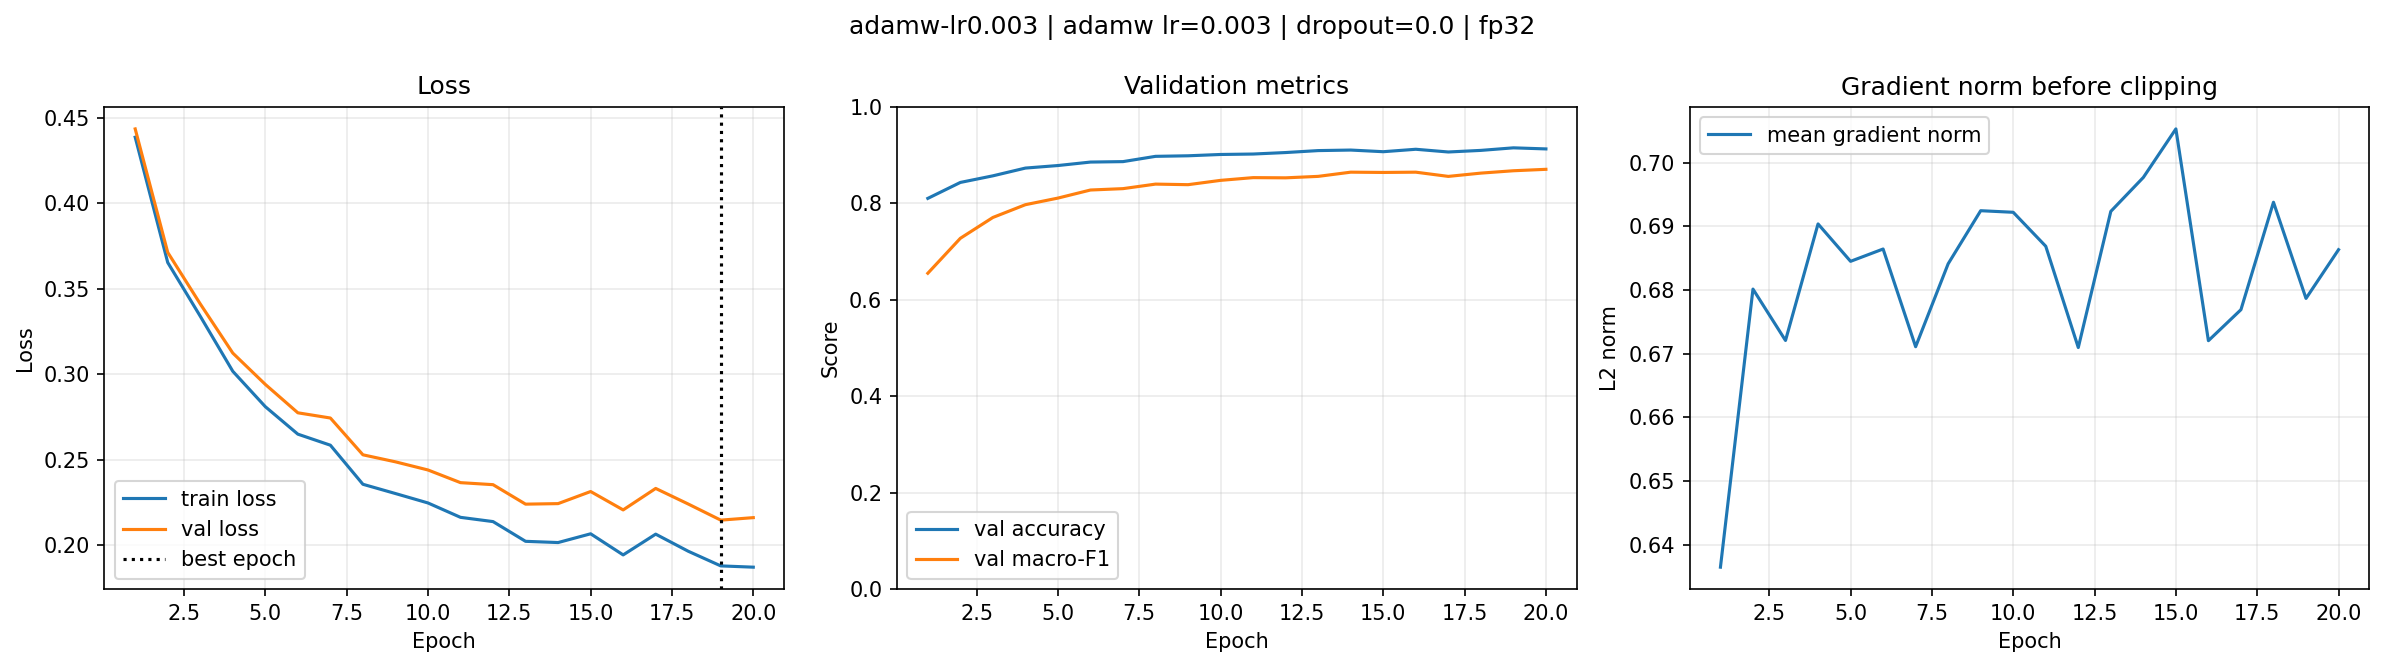

batch2048 Prediction: Batch 2048 giảm số bước/epoch bốn lần so batch 512, có thể làm học chậm với lr giữ nguyên.
Observed F1: 0.7969625312167096 delta: -0.042073225139161785 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


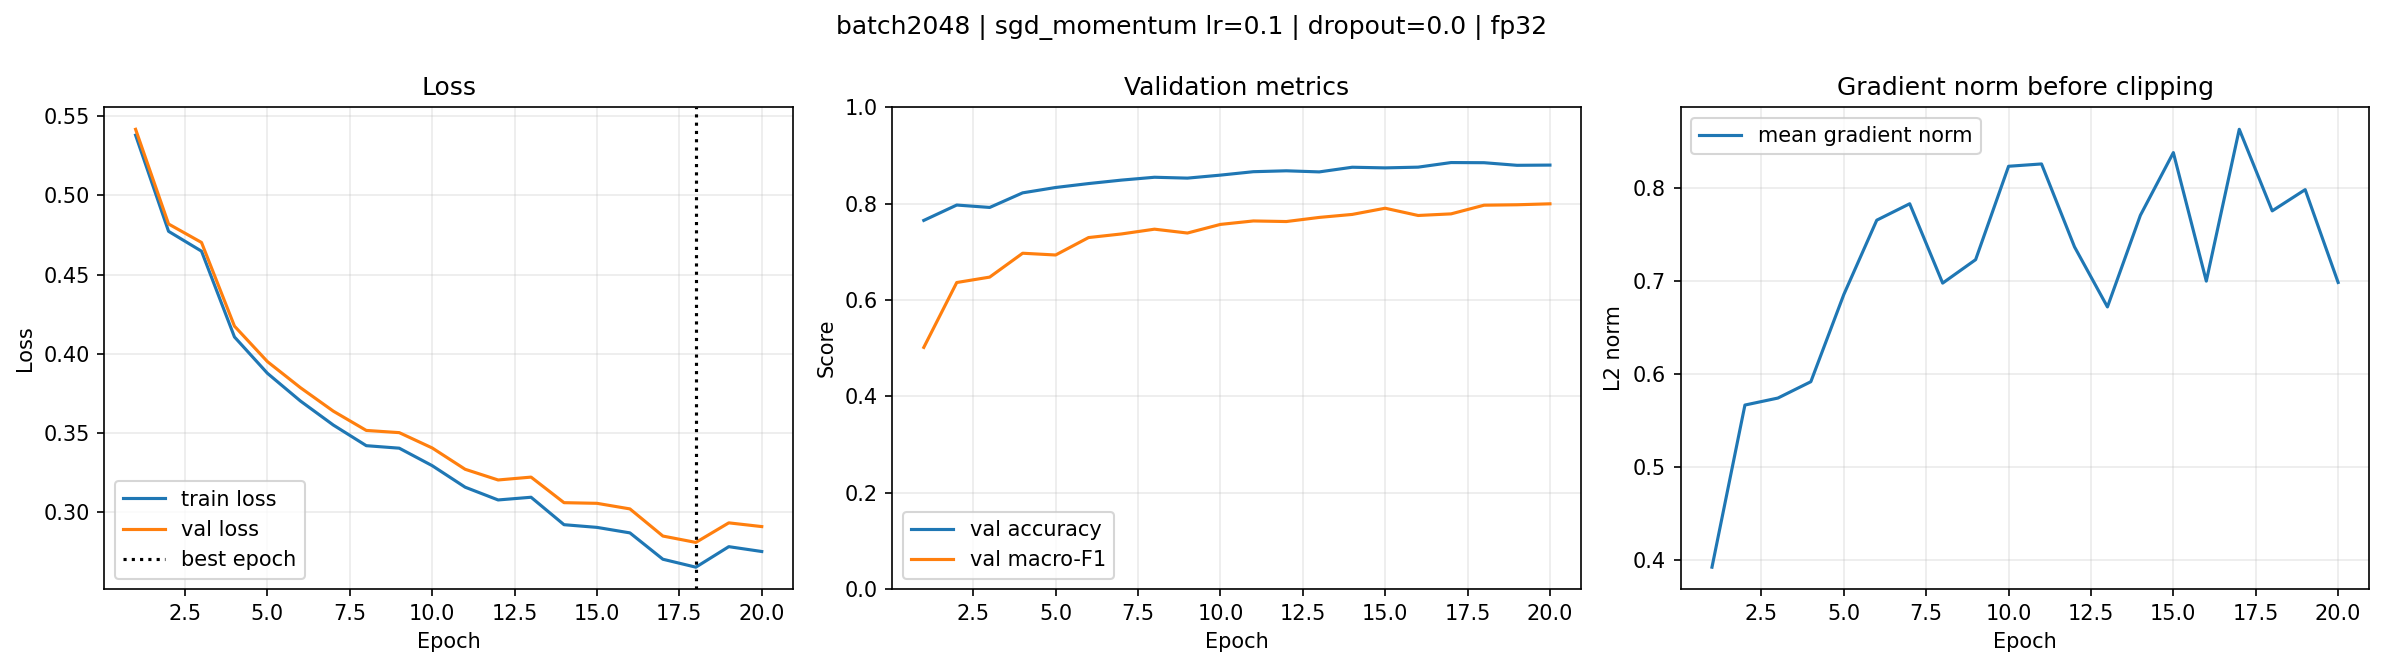

clip-normal Prediction: lr gấp 10 có thể gây dao động; clip ở phân vị 90 gradient baseline có thể giảm bước cực lớn, không chắc cứu được phân kỳ.
Observed F1: 0.8441129852605526 delta: 0.005077228904681208 beyond baseline 2 sigma: False diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


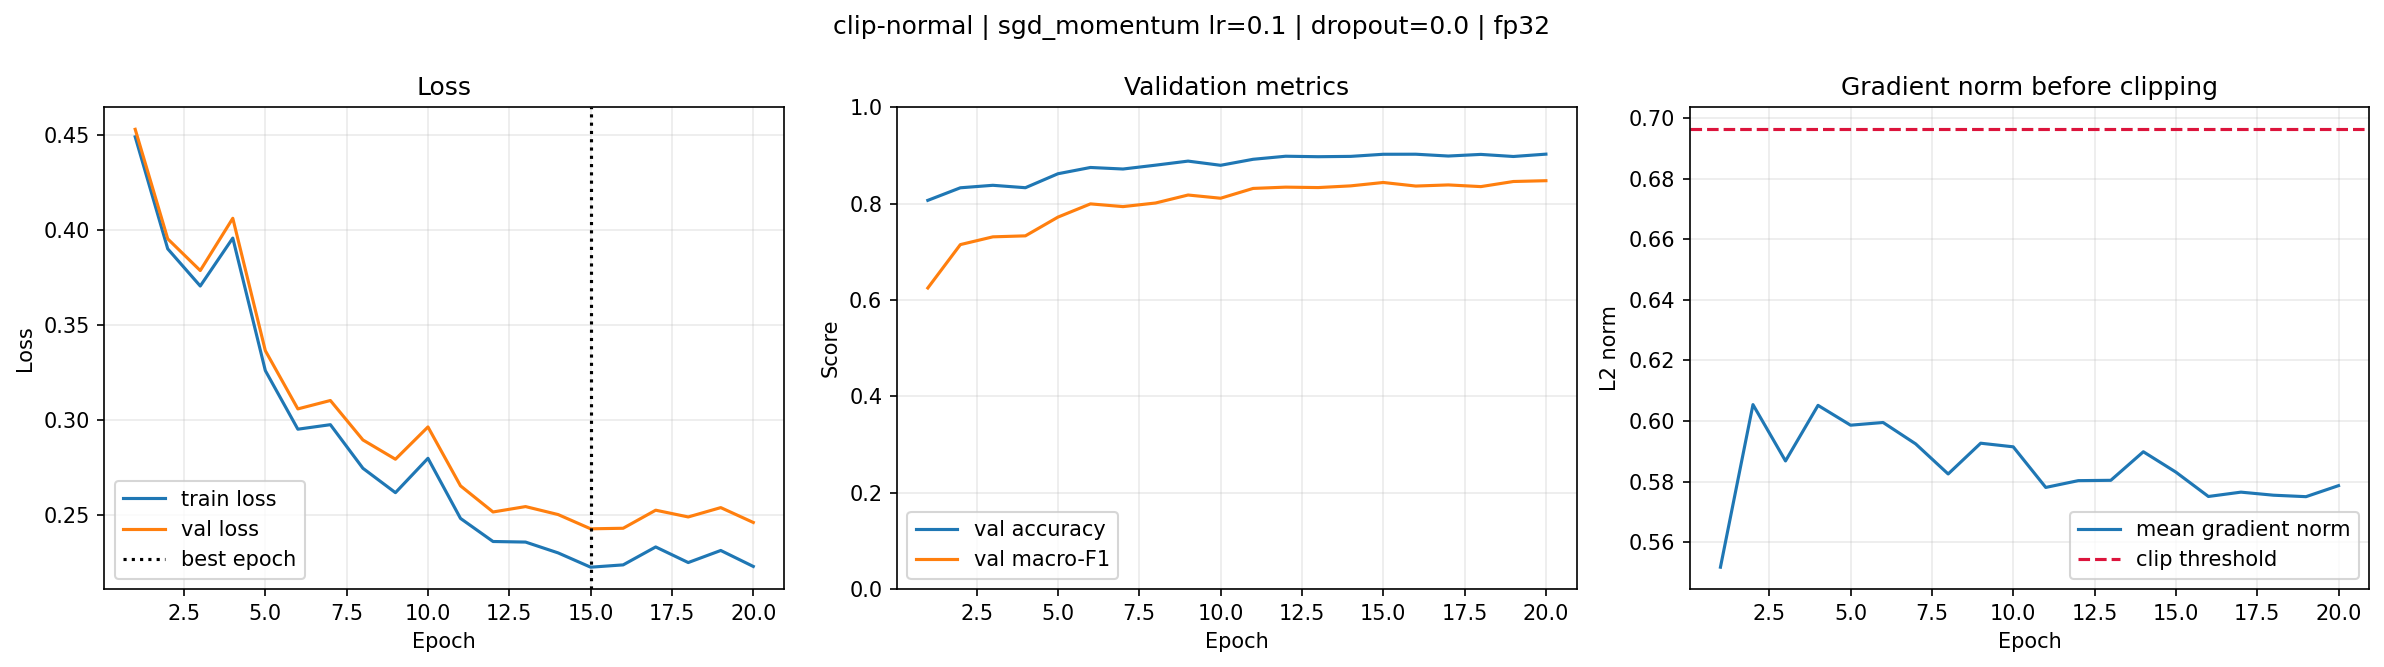

dropout-p03 Prediction: p=0.3 có thể giảm train-val gap nhưng giảm F1 nếu mạng chưa overfit.
Observed F1: 0.7874882114860531 delta: -0.051547544869818274 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


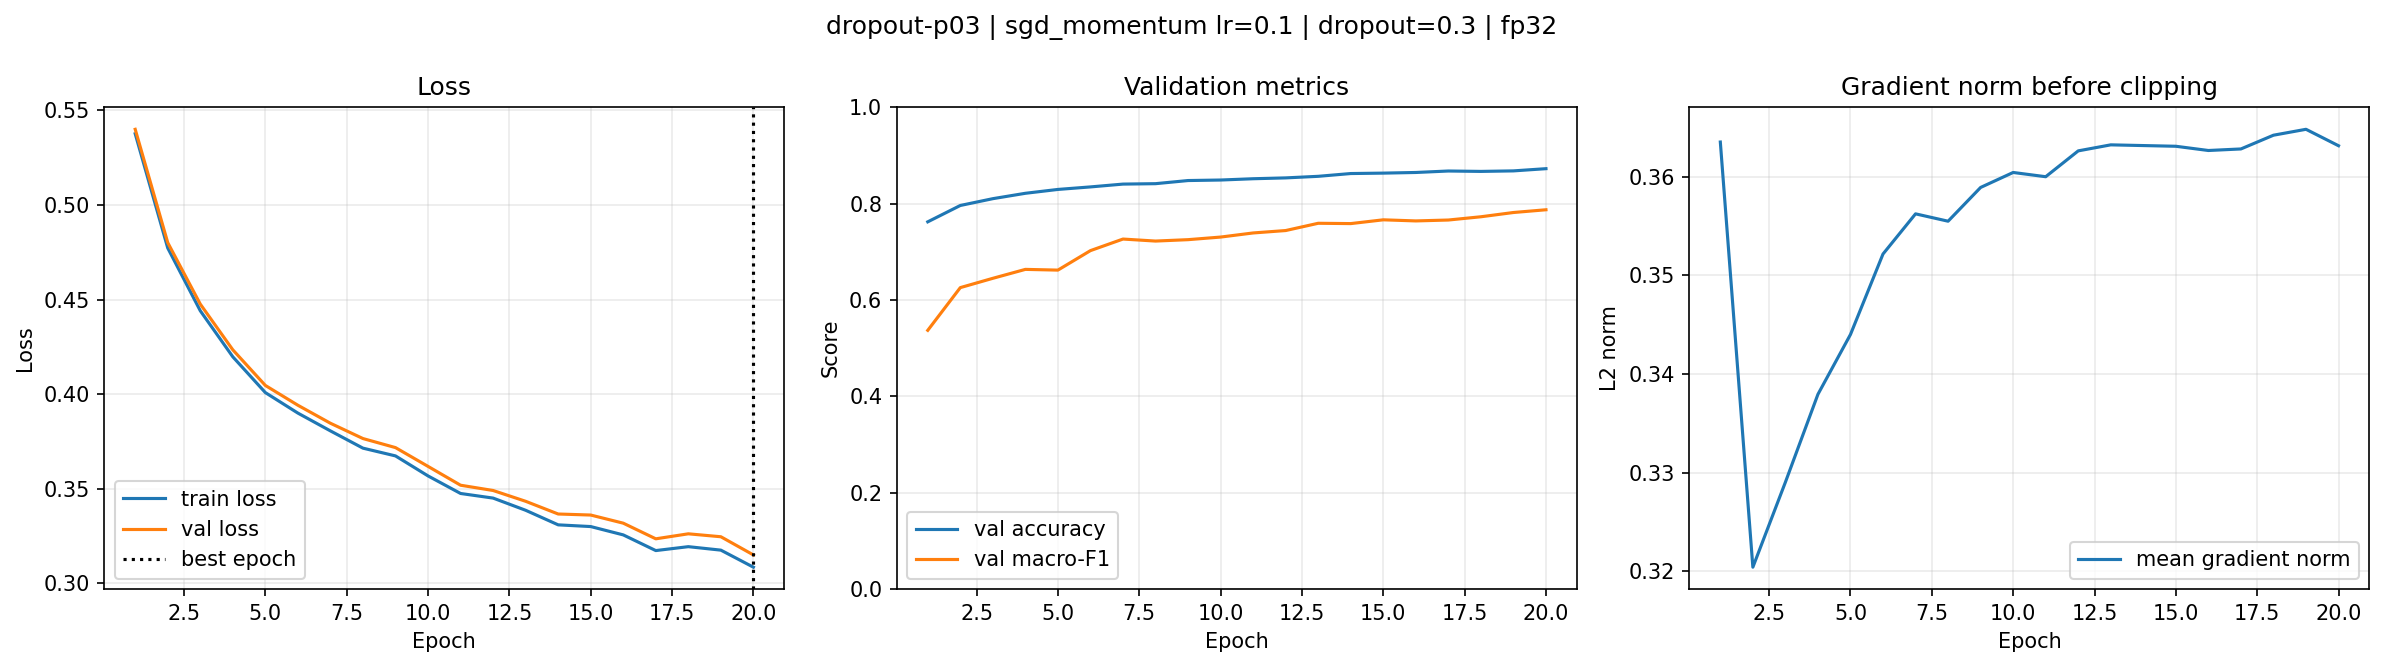

highlr-clip Prediction: lr gấp 10 có thể gây dao động; clip ở phân vị 90 gradient baseline có thể giảm bước cực lớn, không chắc cứu được phân kỳ.
Observed F1: 0.802701640920526 delta: -0.03633411543534537 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


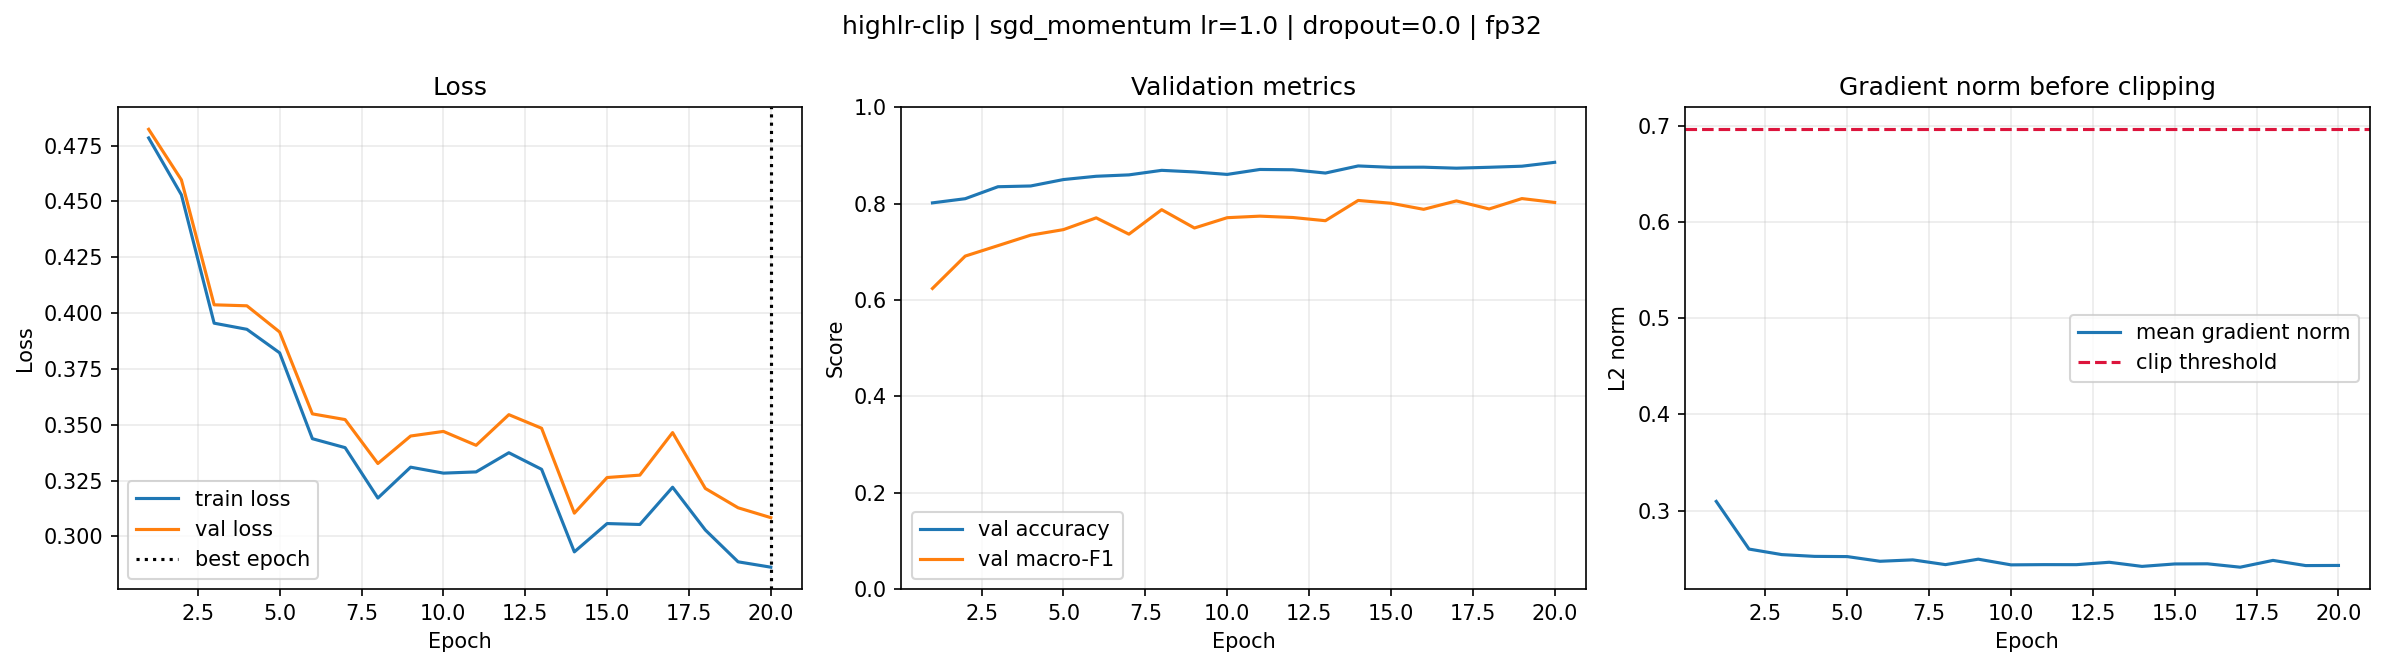

highlr-none Prediction: lr gấp 10 có thể gây dao động; clip ở phân vị 90 gradient baseline có thể giảm bước cực lớn, không chắc cứu được phân kỳ.
Observed F1: 0.7731754847049565 delta: -0.0658602716509149 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


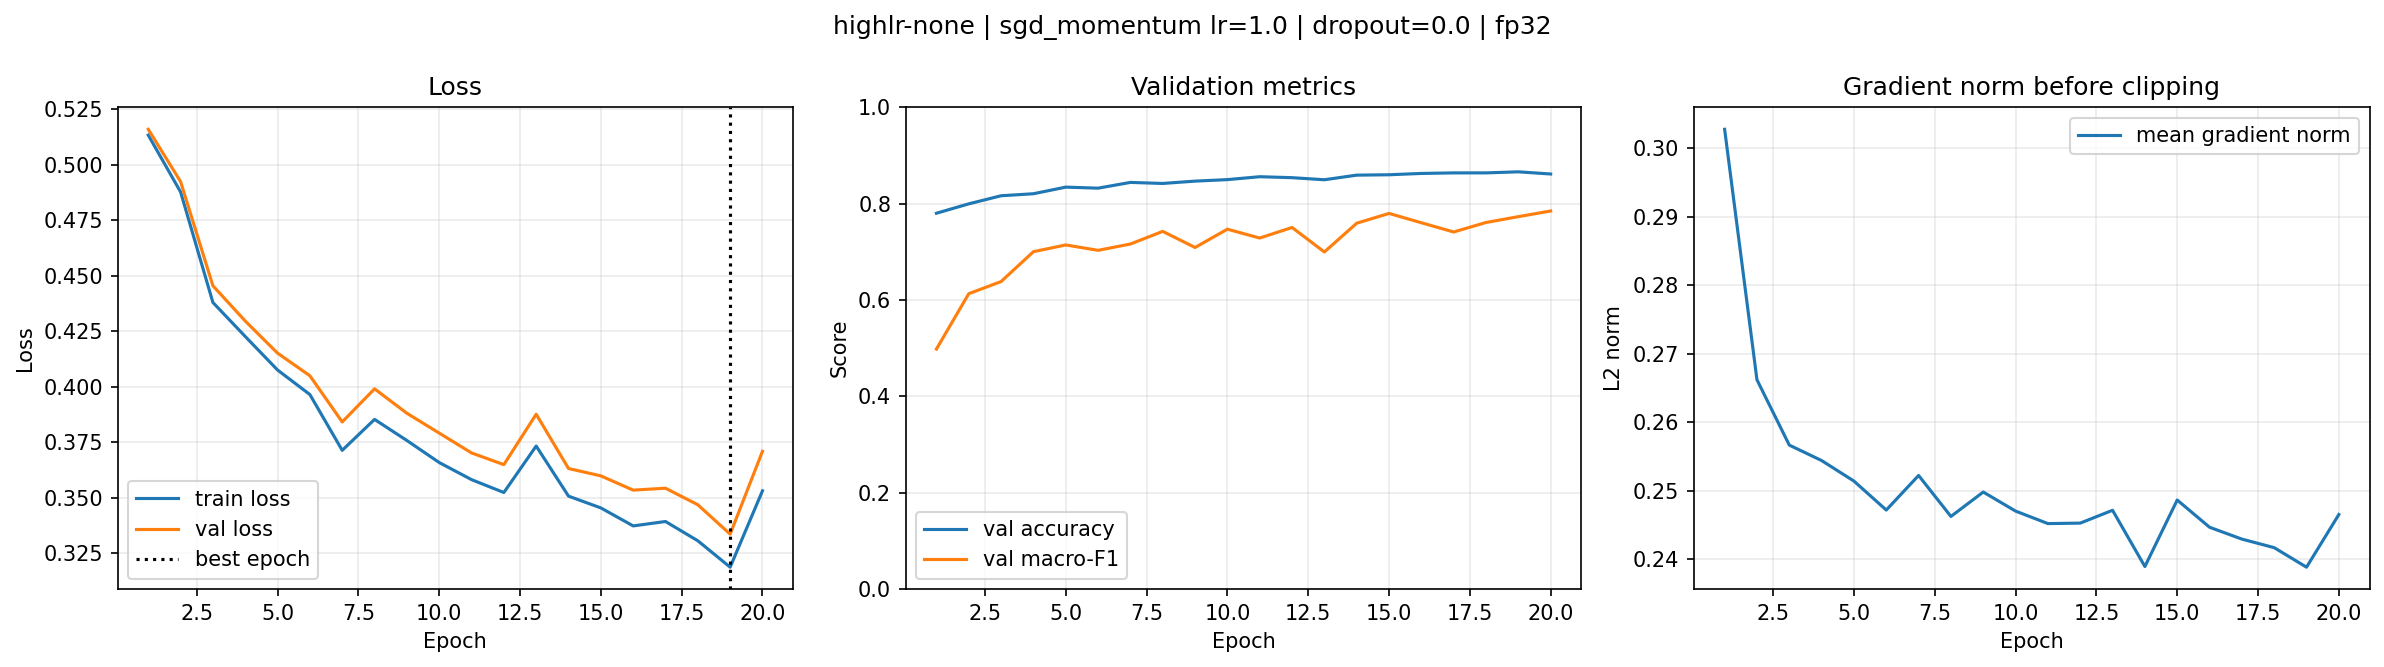

init-normal Prediction: He giữ tín hiệu qua ReLU tốt hơn normal nhỏ; zeros không phá đối xứng và gradient hidden bằng 0.
Observed F1: 0.8449007627822941 delta: 0.005865006426422736 beyond baseline 2 sigma: False diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


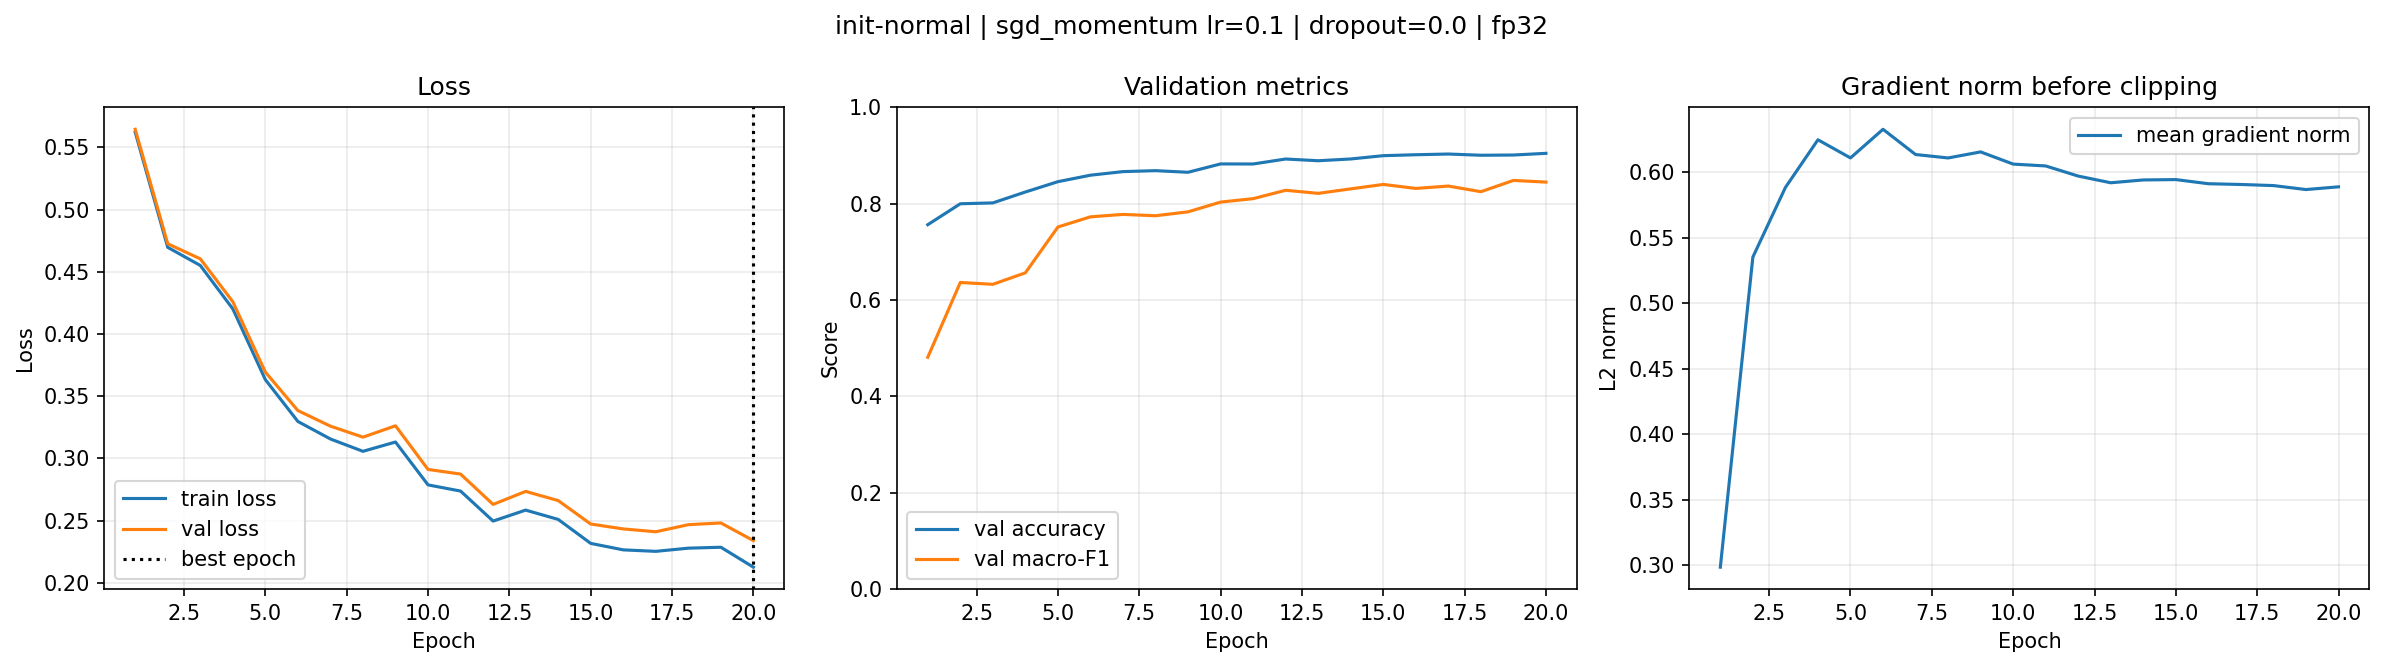

init-xavier Prediction: He giữ tín hiệu qua ReLU tốt hơn normal nhỏ; zeros không phá đối xứng và gradient hidden bằng 0.
Observed F1: 0.8514344709948414 delta: 0.012398714638970021 beyond baseline 2 sigma: False diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


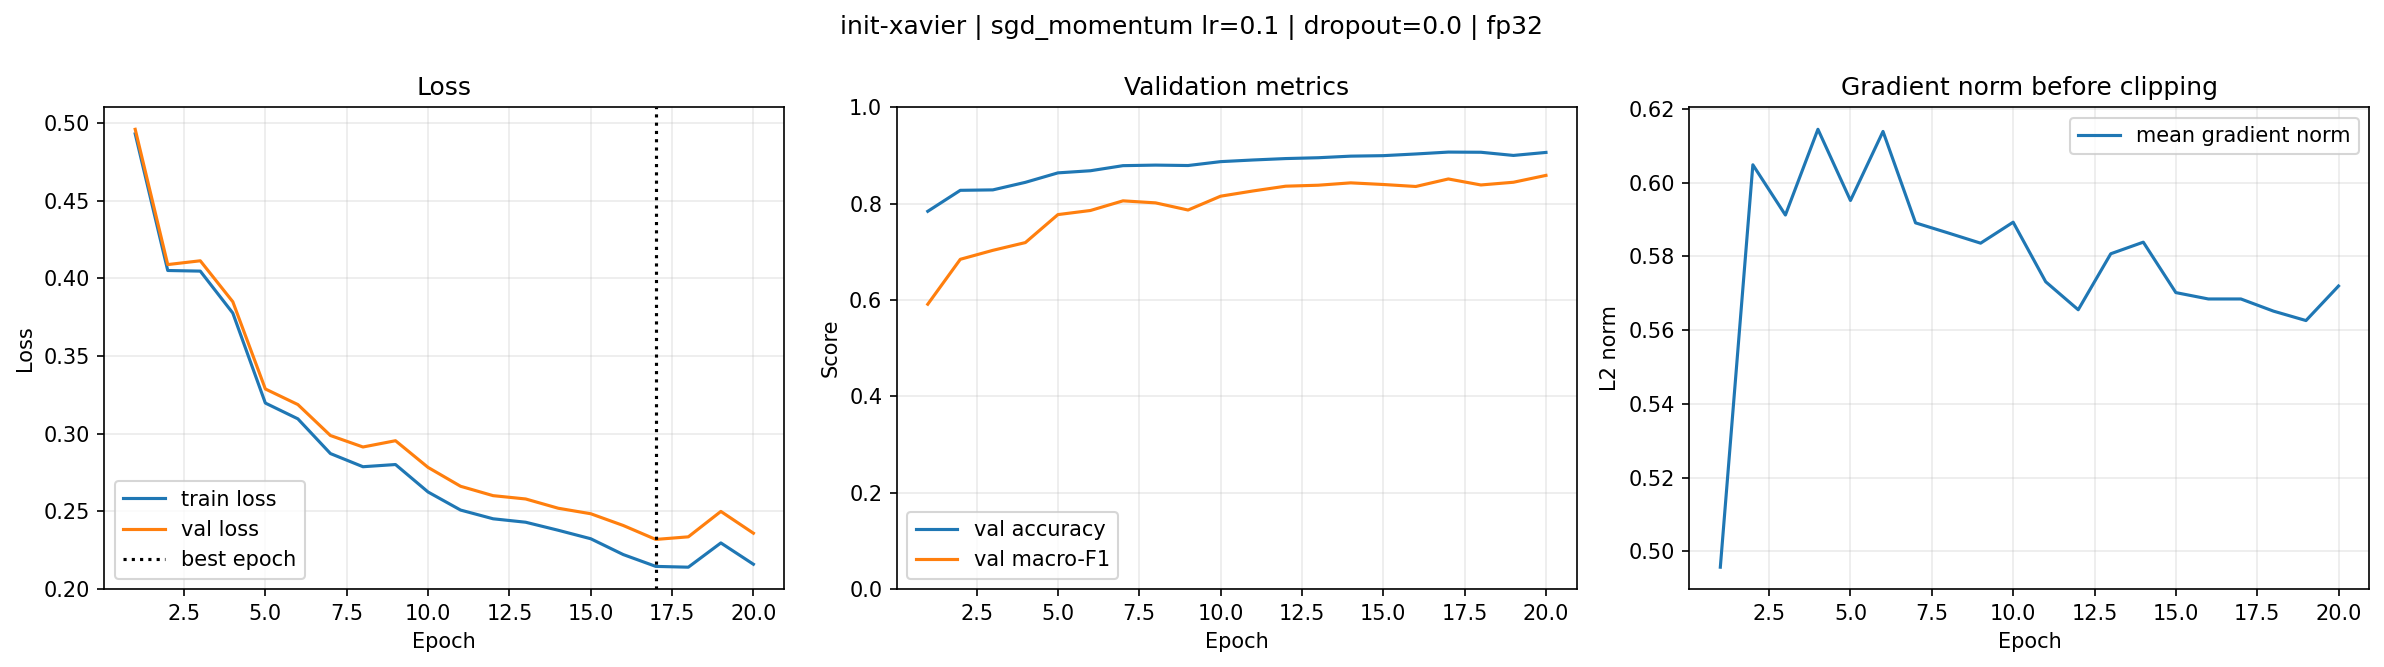

init-zeros Prediction: He giữ tín hiệu qua ReLU tốt hơn normal nhỏ; zeros không phá đối xứng và gradient hidden bằng 0.
Observed F1: 0.09364999018625454 delta: -0.7453857661696168 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


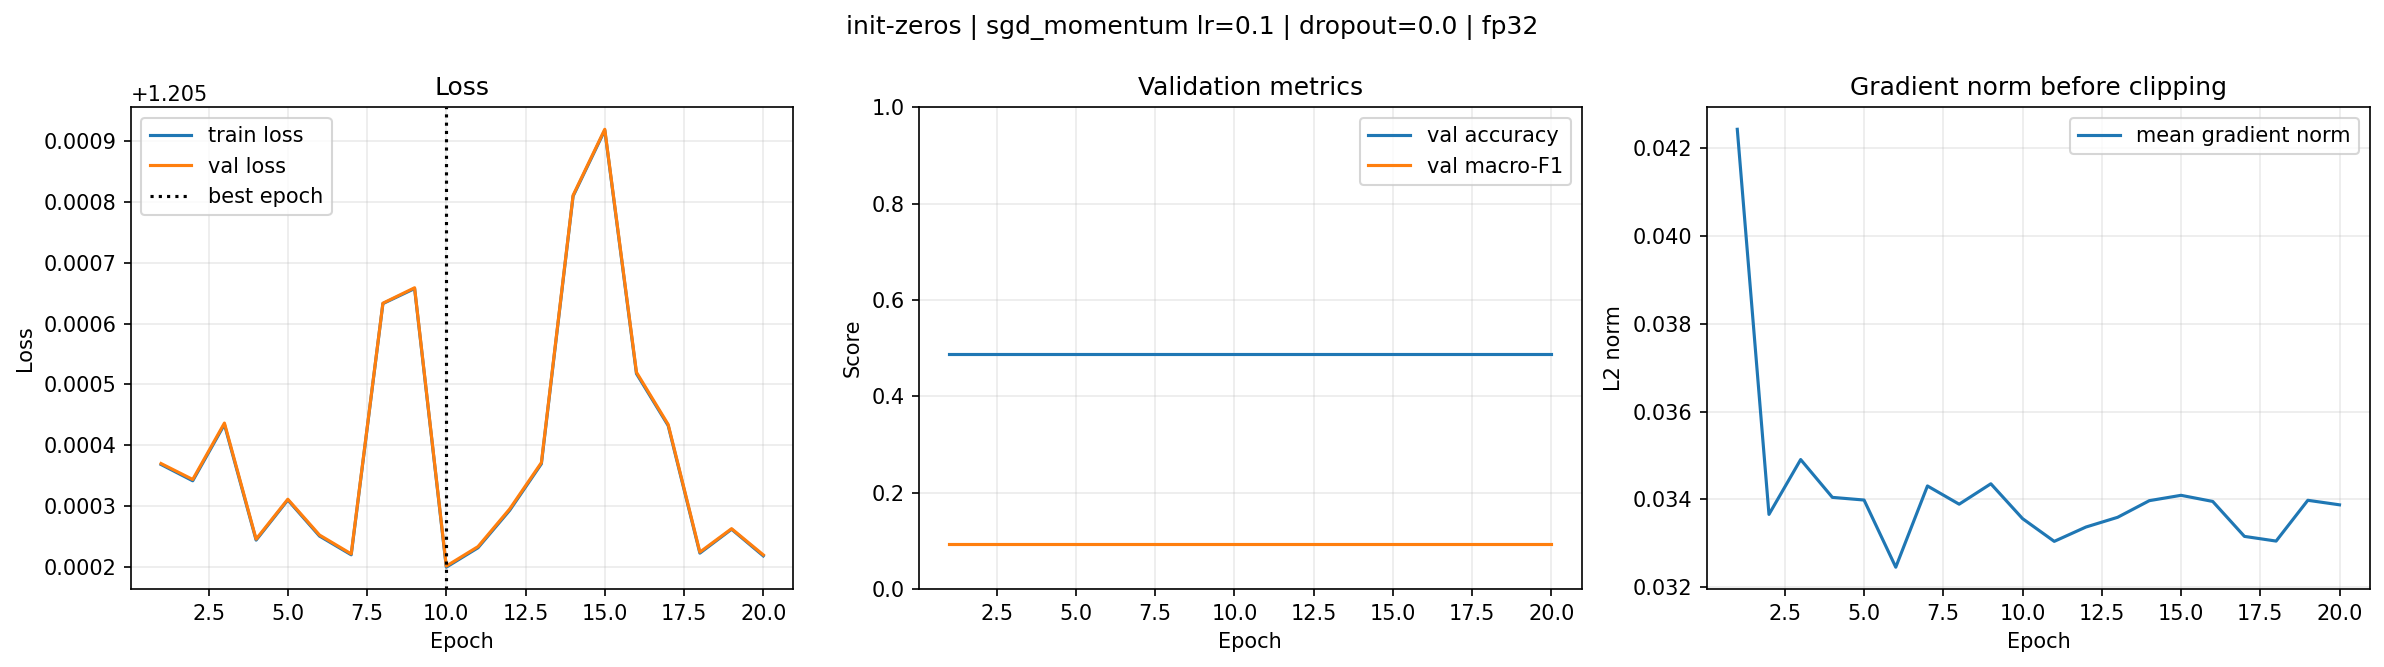

loss-mse Prediction: CE phù hợp phân lớp hơn MSE logits/one-hot; chỉ so accuracy/F1, không so trị số loss khác thang.
Observed F1: 0.7276654739925651 delta: -0.11137028236330626 beyond baseline 2 sigma: True diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


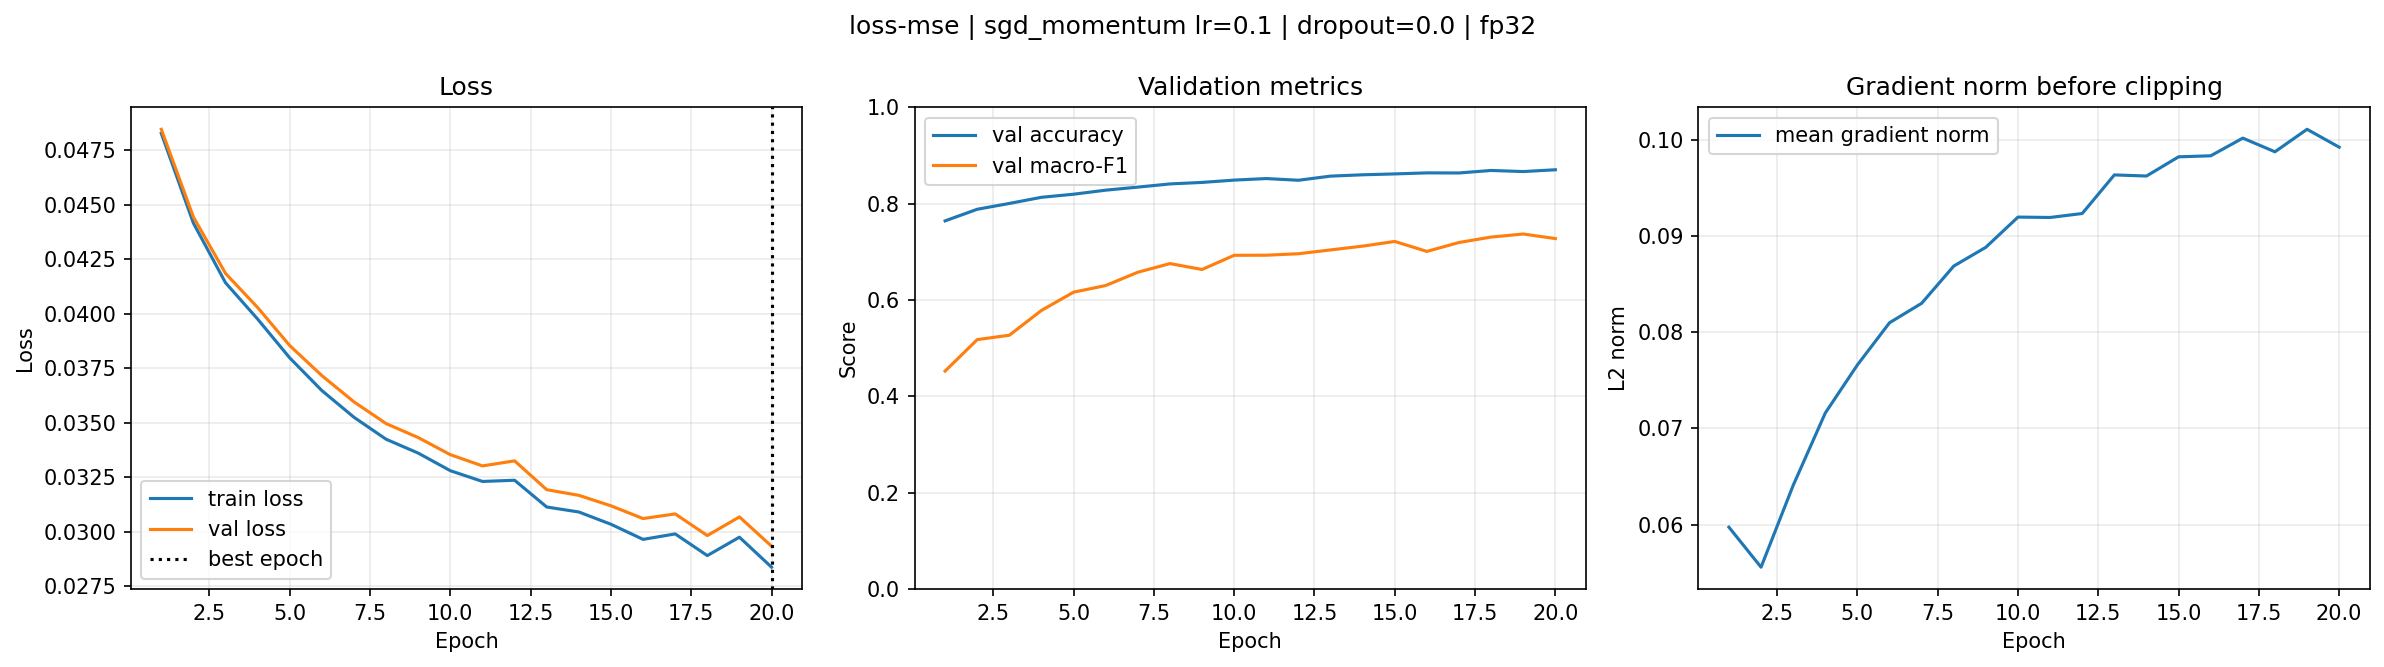

precision-bf16 Prediction: FP16/BF16 có thể không nhanh hơn với MLP nhỏ; T4 không có BF16 native, nên tốc độ BF16 chỉ là số đo emulation.
Observed F1: 0.8366261256178422 delta: -0.0024096307380291337 beyond baseline 2 sigma: False diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


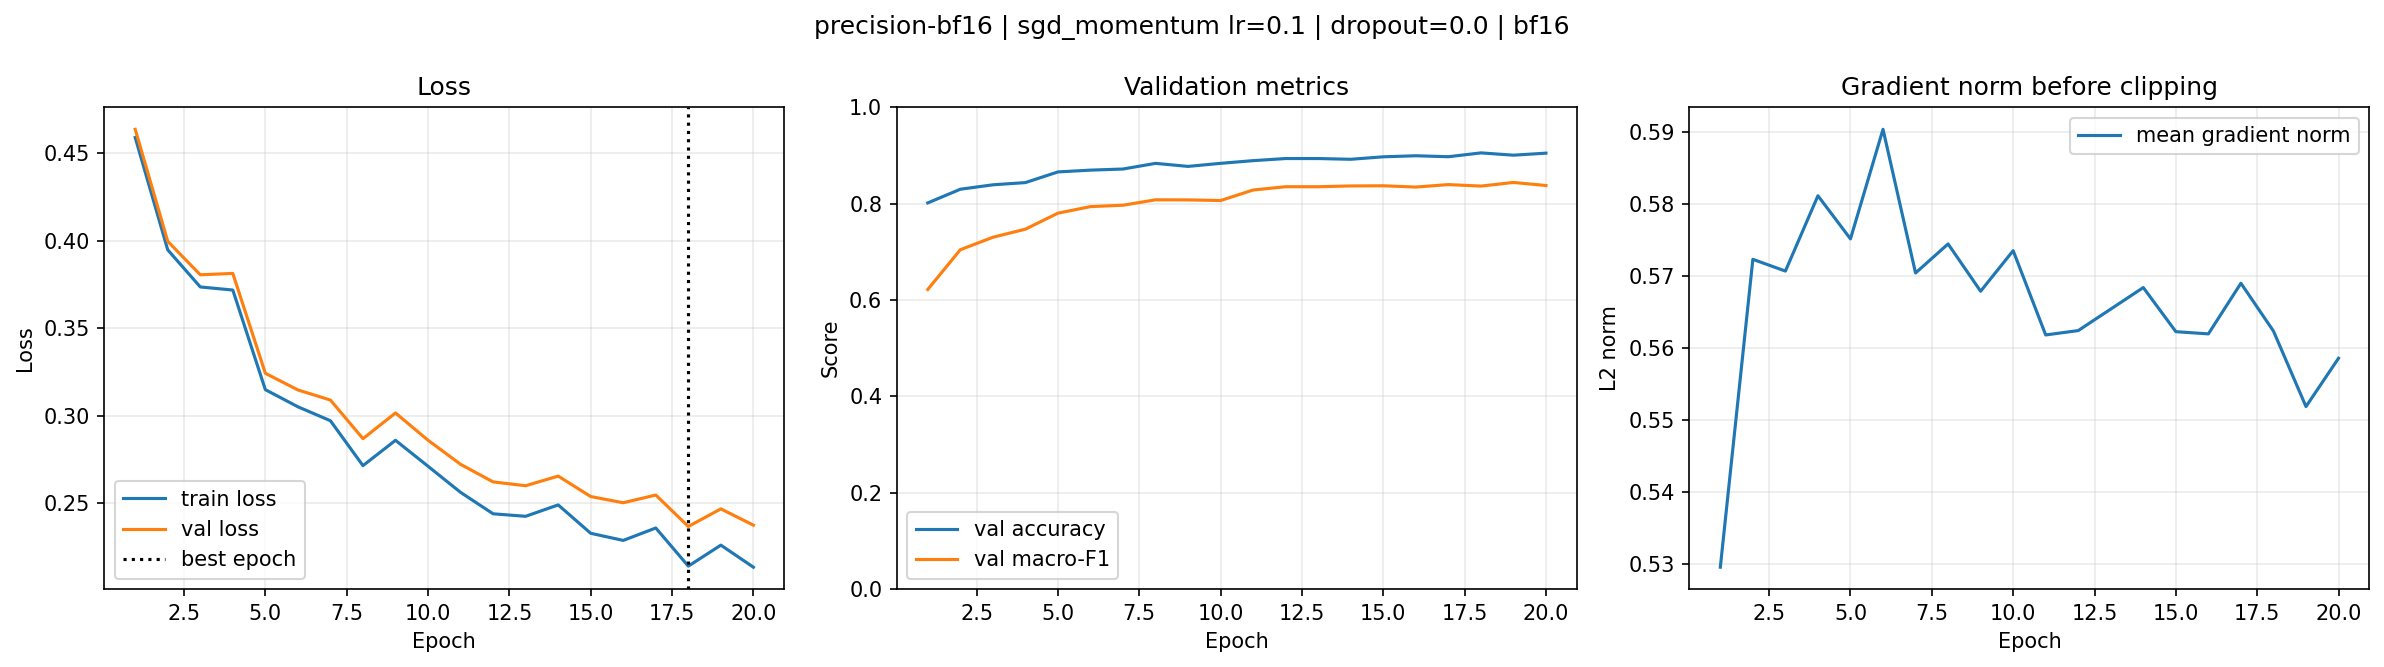

precision-fp16 Prediction: FP16/BF16 có thể không nhanh hơn với MLP nhỏ; T4 không có BF16 native, nên tốc độ BF16 chỉ là số đo emulation.
Observed F1: 0.8515042026567495 delta: 0.012468446300878178 beyond baseline 2 sigma: False diverged: False
One seed: interpret as exploratory; inspect loss, gradient, time, memory below.


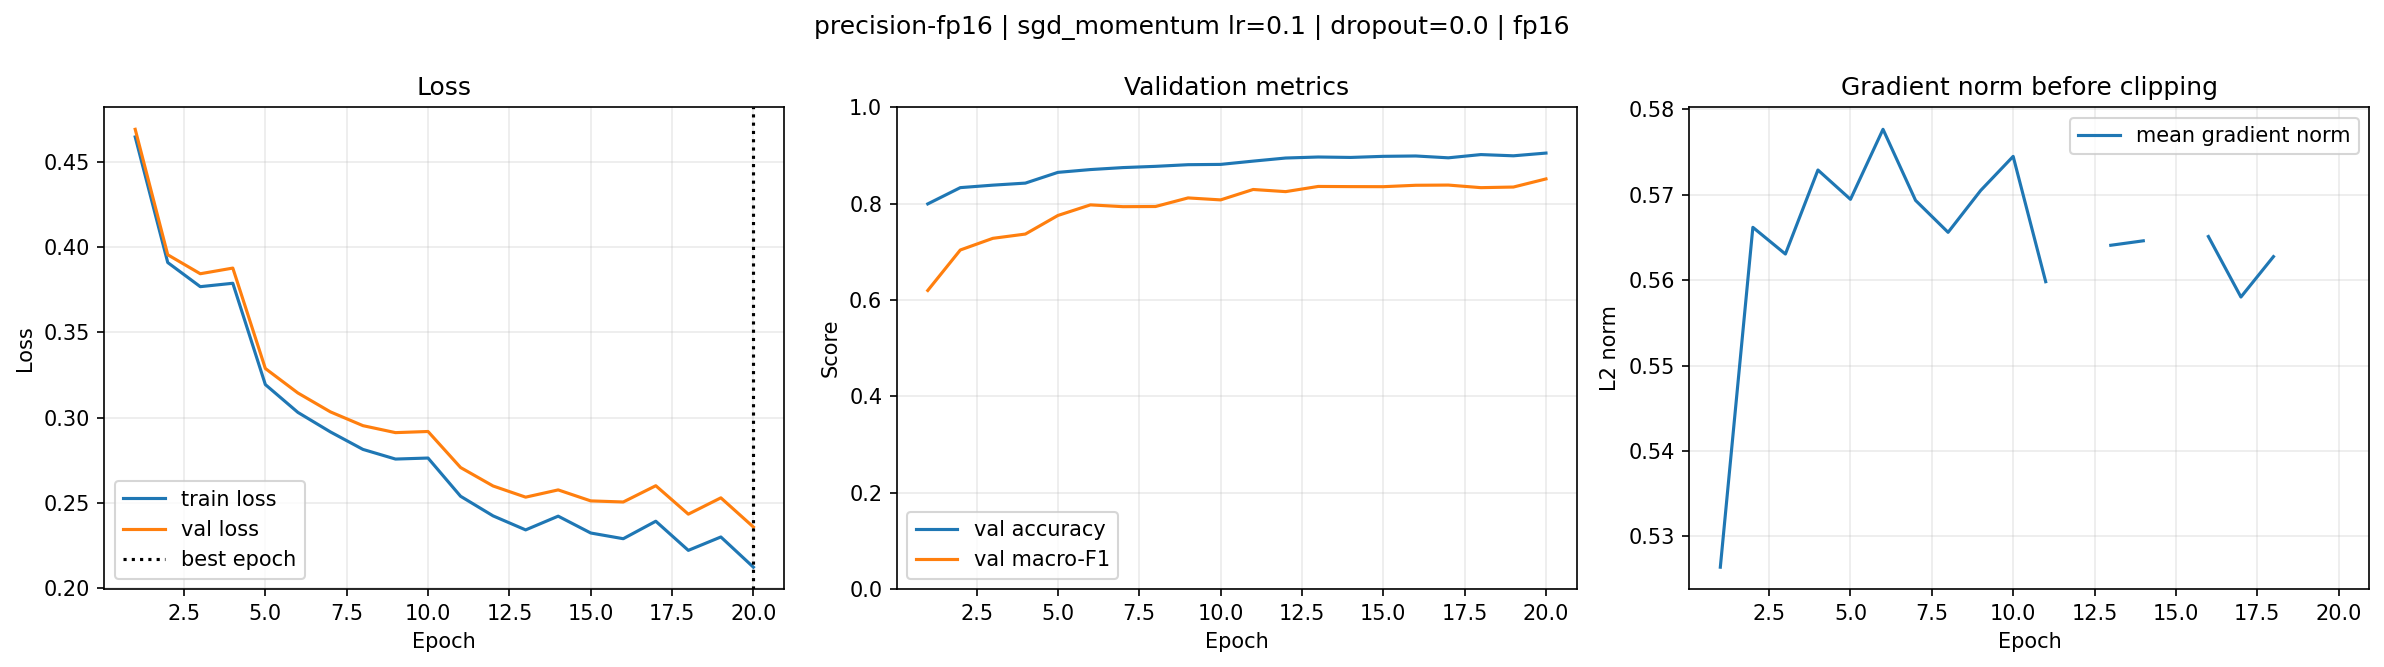

In [6]:
from protocol import PREDICTIONS
results=load_results(OUT/'results')
base=next(r for r in results if r['cfg']['exp_id']=='base-s1')
noise=2*np.std([r['summary']['val_macro_f1'] for r in seeds],ddof=1)
for r in results:
    if r['cfg']['group']=='baseline': continue
    delta=r['summary']['val_macro_f1']-base['summary']['val_macro_f1']
    print(r['cfg']['exp_id'], 'Prediction:',PREDICTIONS[r['cfg']['group']])
    print('Observed F1:',r['summary']['val_macro_f1'],'delta:',delta,'beyond baseline 2 sigma:',abs(delta)>noise,'diverged:',r['summary']['diverged'])
    print('One seed: interpret as exploratory; inspect loss, gradient, time, memory below.')
    display(Image(filename=str(OUT/'figures'/f"{r['cfg']['exp_id']}.png")))

## Part 4 — Khoá cấu hình, eval, báo cáo và bài nộp

Chọn F1 validation cao nhất trong các run không diverged seed1 (tie: exp_id), checkpoint min val loss. Lặp seed2/3 để đo noise, không dùng để đổi cấu hình. Chỉ scoring baseline và cấu hình cuối sau khi đã khoá lựa chọn. Eval cũ đã được biết: báo cáo minh bạch hạn chế này.

In [7]:
stage('select')
print('SELECTION_FROZEN_BEFORE_EVAL',json.loads((OUT/'protocol.json').read_text(encoding='utf-8'))['selected_exp_id'])
stage('score')

FINAL_CONFIG_FROZEN {'exp_id': 'adam-lr0.003', 'group': 'optimizer', 'description': 'Adam/AdamW có thể hội tụ nhanh hơn SGD; thử cùng lưới lr cho từng optimizer và so lr tốt nhất.', 'loss': 'ce', 'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 512, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}


SELECTION_FROZEN_BEFORE_EVAL adam-lr0.003


FINAL_EVAL_COMPLETE


SUBMISSION_COMPLETE {"baseline": {"n_eval": 116203, "accuracy": 0.9033415660525116, "macro_f1": 0.8409922038067058, "per_class": [{"cls": 0, "support": 42368, "precision": 0.9015601432880844, "recall": 0.9029220166163142, "f1": 0.9022405660377357}, {"cls": 1, "support": 56661, "precision": 0.9092774970247849, "recall":


# Báo cáo Lab Day 1 — Hoàng Trung Anh — 2A202602521



## 1. Thiết lập

Colab Tesla T4, PyTorch 2.11.0+cu130. M-base 54→256→128→7, 47 879 tham số, ReLU, logits thô. Metadata train/eval 464 809/116 203; validation 20%, stratify seed 42: 371 847 train/92 962 val. Chuẩn hoá 10 cột từ train; giữ 44 cột nhị phân. Majority val accuracy=0.487597.

Baseline đúng GUIDE: SGD momentum 0,9, lr=0.1, batch 512, 20 epoch, CE, He, FP32; không dropout/clip/weight decay. Lr chọn từ 0.01/0.05/0.1 bằng val. Mỗi run khởi chạy process GPU độc lập; batch cuối giữ lại. Adam/AdamW thử 0.0003/0.001/0.003. Đã thử đủ 7 chủ đề. Mọi số liệu có trong Experiments/Seeds/Summary, tra theo exp_id; cấu hình và giả thuyết ghi trước trong protocol.json/planned/.



## 2. Kiểm tra ban đầu và độ nhiễu

Logits (20,7); gradient khác 0 ở mọi tham số. Overfit 20 mẫu: accuracy=1.000000, loss=0.00000439 sau 500 bước Adam lr=.01. Loss uniform logits=1.945910=ln 7. He step-0 CE=2.269062; logits ngẫu nhiên có phương sai nên CE không 

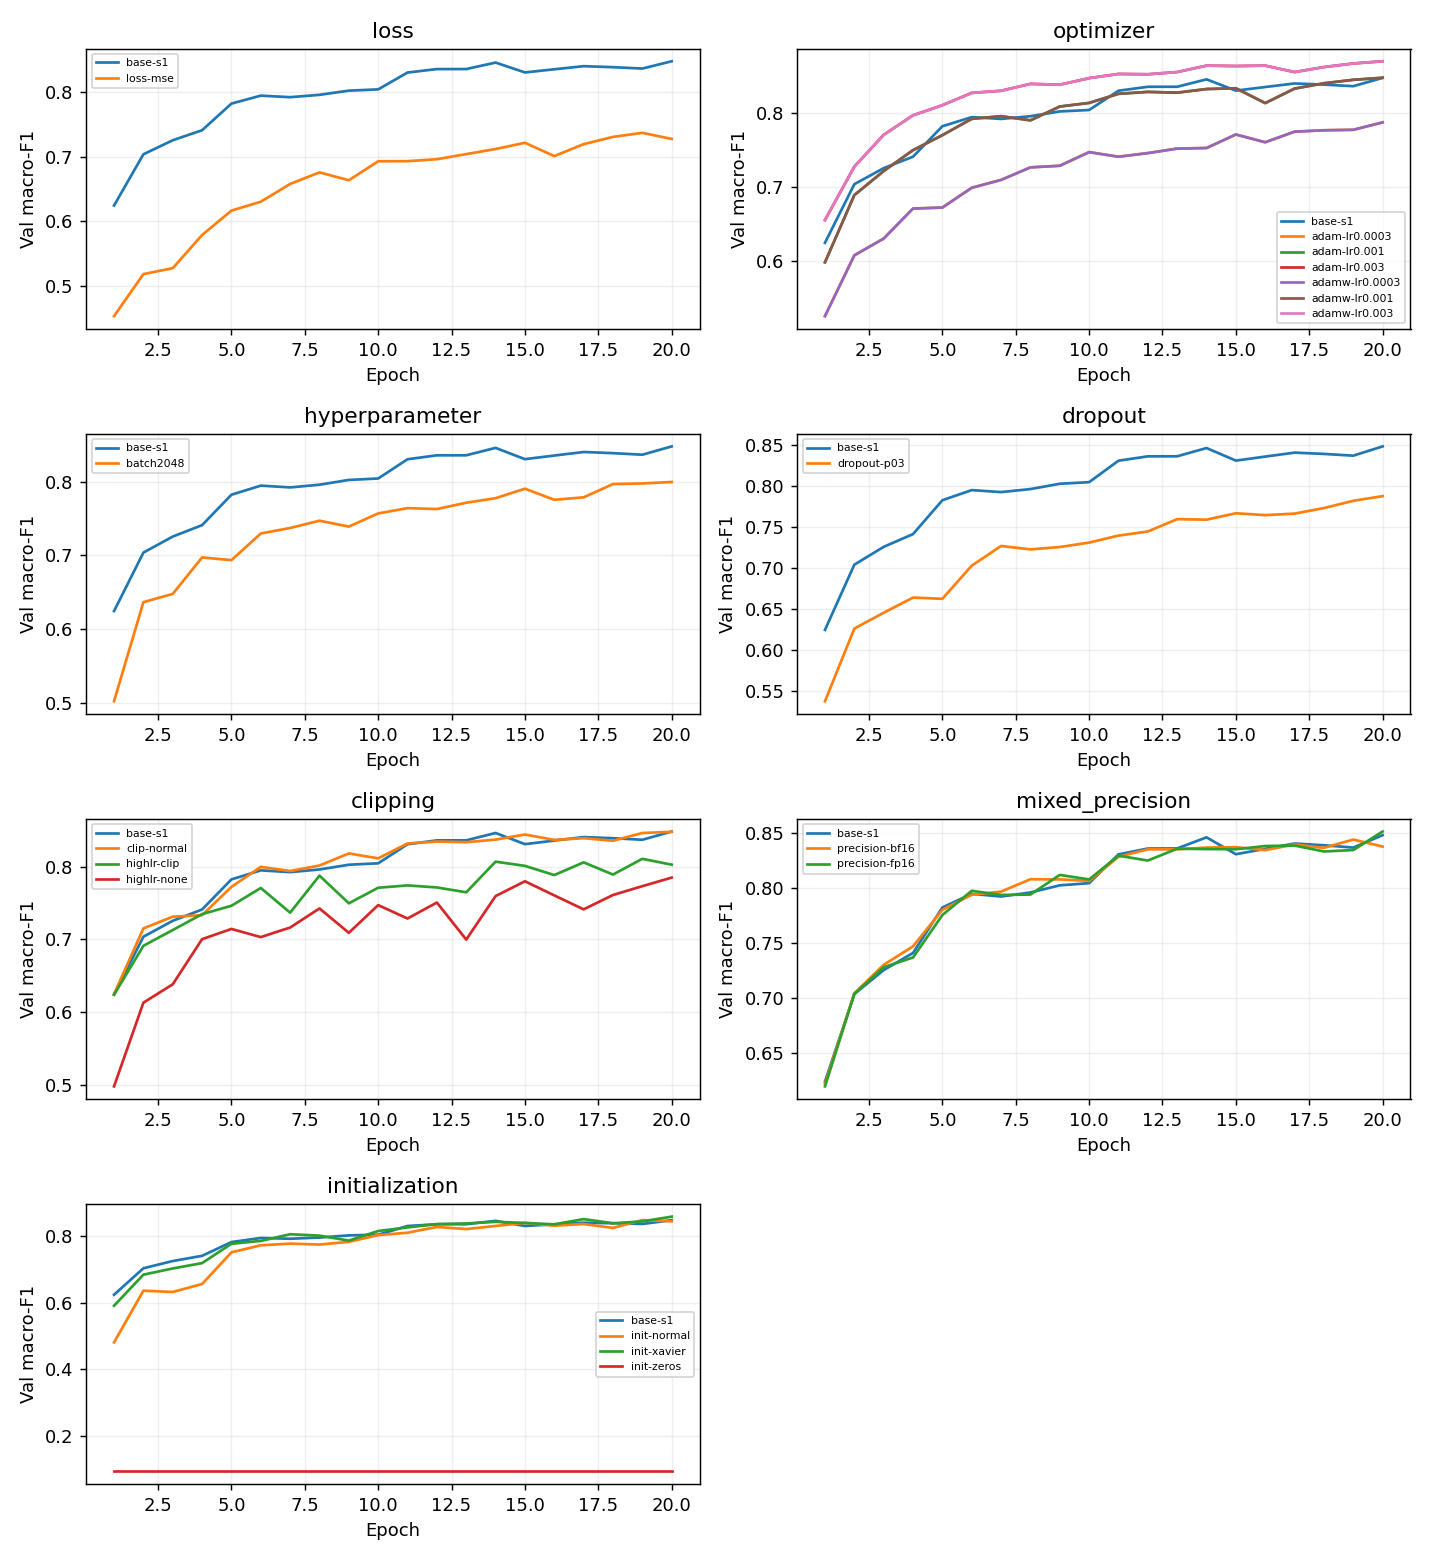

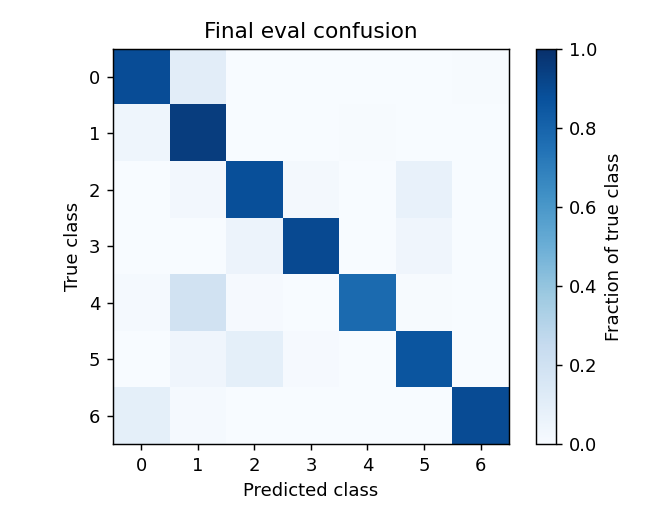

RESTART_RUN_ALL_COMPLETE


In [8]:
from revision_report import finish
finish()
print((OUT/'REPORT.md').read_text(encoding='utf-8'))
display(Image(filename=str(OUT/'figures/compare_all.png')))
display(Image(filename=str(OUT/'figures/confusion_eval.png')))
print('RESTART_RUN_ALL_COMPLETE')